# Project 4: Diffusion Models

1. Setup
2. Task 1: 1D Forward Diffusion
3. Task 1: Closed-Form Reverse Process
4. Task 2: 2D Point Data
5. Task 2: Model and Diffusion Utilities
6. Task 2: Training Function
7. Task 2: Train Circle / Square / Dinohead
8. Task 2: Sampling and Visualization
9. Hyperparameter Analysis
10. Optional Advanced Part
11. Figures for Report

### Report notes
- Explain the forward diffusion process and why x_T approaches a standard normal.
- Derive and explain the closed-form reverse process for Task 1.
- Describe the MLP architecture, sinusoidal embeddings, optimizer, learning rate, and number of training steps.
- Explain reverse sampling at inference time.
- Show generated results at multiple training stages.
- Discuss one hyperparameter effect.
- Identify 1–2 qualitative artifacts and connect them to the independent-point assumption.

# Project IV: Diffusion Models

This notebook contains the implementation and experimental evaluation for Project IV on diffusion models. The project consists of two mandatory tasks. In the first task, I study a one-dimensional diffusion process where the forward process is known analytically and the reverse process can be derived in closed form. In the second task, I train diffusion-based neural networks to generate two-dimensional point clouds corresponding to three target shapes: a circle, a square, and a dinosaur head.

The notebook is organized as follows. First, I introduce the forward and reverse processes for the one-dimensional setting and verify that repeated noising transforms samples toward a standard Gaussian distribution. Next, I implement a neural diffusion model for two-dimensional point generation using sinusoidal embeddings and a multilayer perceptron trained to predict the noise added at a randomly chosen diffusion step. Finally, I present generated samples at different training stages, compare selected hyperparameter settings, and discuss characteristic artifacts in the generated point clouds.

The implementation is written in Python using PyTorch. Figures produced in this notebook are reused in the report, which describes the method and experimental results in a more compact format.

## 1. Setup

In this section, I import the required libraries, define common plotting utilities, and fix the main hyperparameters used throughout the notebook. I also select the computation device and set the random seed to improve reproducibility. Keeping the configuration in one place makes it easier to compare multiple experiments consistently.

In [ ]:
import os
import json
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/task1", exist_ok=True)
os.makedirs("outputs/task2", exist_ok=True)

Device: cpu


In [10]:
# Global config

CONFIG = {
    "T": 50,
    "schedule": "linear",      # "linear", "quadratic", or "constant"
    "beta_start": 1e-4,
    "beta_end": 2e-2,
    "batch_size": 256,
    "lr": 1e-3,
    "num_steps": 20000,
    "coord_emb_dim": 64,
    "time_emb_dim": 64,
    "hidden_dim": 128,
    "num_hidden_layers": 3,
    "save_every": 1000,
    "sample_size": 1024,
}
CONFIG

{'T': 50,
 'schedule': 'linear',
 'beta_start': 0.0001,
 'beta_end': 0.02,
 'batch_size': 256,
 'lr': 0.001,
 'num_steps': 20000,
 'coord_emb_dim': 64,
 'time_emb_dim': 64,
 'hidden_dim': 128,
 'num_hidden_layers': 3,
 'save_every': 1000,
 'sample_size': 1024}

In [11]:
# Plot
def plot_1d_trajectories(trajectories, save_path=None, title="1D trajectories"):
    plt.figure(figsize=(7, 4))
    for tr in trajectories:
        plt.plot(tr, alpha=0.8)
    plt.xlabel("t")
    plt.ylabel("x_t")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()
    plt.close()

def plot_histogram(values, bins=40, save_path=None, title="Histogram"):
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins, alpha=0.8)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()
    plt.close()

def plot_points(points, save_path=None, title="2D points", equal_axis=True):
    if isinstance(points, torch.Tensor):
        points = points.detach().cpu().numpy()
    plt.figure(figsize=(5, 5))
    plt.scatter(points[:, 0], points[:, 1], s=6, alpha=0.75)
    if equal_axis:
        plt.axis("equal")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=220)
    plt.show()
    plt.close()

def plot_loss(losses, save_path=None, title="Training loss"):
    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    plt.xlabel("Training step")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=220)
    plt.show()
    plt.close()

## 2. Task 1: One-Dimensional Forward Diffusion

The first mandatory task studies a one-dimensional diffusion process. I begin by defining an initial distribution \(x_0 \sim \mathcal{N}(m, p)\), where the parameters are chosen so that the distribution is clearly different from a standard Gaussian. I then simulate the forward diffusion process for \(T = 50\) steps and visualize several trajectories to show how the samples gradually lose information about the original distribution.

To evaluate the final state of the forward process, I generate many trajectories and inspect the empirical distribution of \(x_T\). The objective is to verify that after repeated noise injection, the distribution becomes approximately standard normal.

In [12]:
# Task 1: 1D diffusion 
def make_beta_schedule(T, schedule="linear", beta_start=1e-4, beta_end=2e-2):
    if schedule == "linear":
        betas = np.linspace(beta_start, beta_end, T, dtype=np.float64)
    elif schedule == "quadratic":
        betas = np.linspace(beta_start**0.5, beta_end**0.5, T, dtype=np.float64) ** 2
    elif schedule == "constant":
        betas = np.full(T, beta_end, dtype=np.float64)
    else:
        raise ValueError("Unknown schedule.")
    return betas

class Diffusion1D:
    def __init__(self, T=50, schedule="constant", beta_start=1e-4, beta_end=0.25):
        self.T = T
        self.betas = make_beta_schedule(T, schedule, beta_start, beta_end)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = np.cumprod(self.alphas)

    def sample_x0(self, n=100, mean=2.0, var=0.5):
        return np.random.normal(mean, np.sqrt(var), size=n)

    def forward_step(self, x_prev, t):
        noise = np.random.randn(*np.shape(x_prev))
        x_t = np.sqrt(self.alphas[t]) * x_prev + np.sqrt(self.betas[t]) * noise
        return x_t, noise

    def run_forward_trajectory(self, x0_scalar):
        xs = [x0_scalar]
        x = x0_scalar
        for t in range(self.T):
            x, _ = self.forward_step(x, t)
            xs.append(x)
        return np.array(xs)

## 3. Task 1: Forward Process Results

The following figures visualize the forward diffusion process. First, I plot several individual trajectories to illustrate how the samples evolve over time. Second, I show a histogram of the final states \(x_T\) over a larger set of trajectories. Together, these plots demonstrate the progressive destruction of information in the original samples and the convergence toward a noise-dominated distribution.

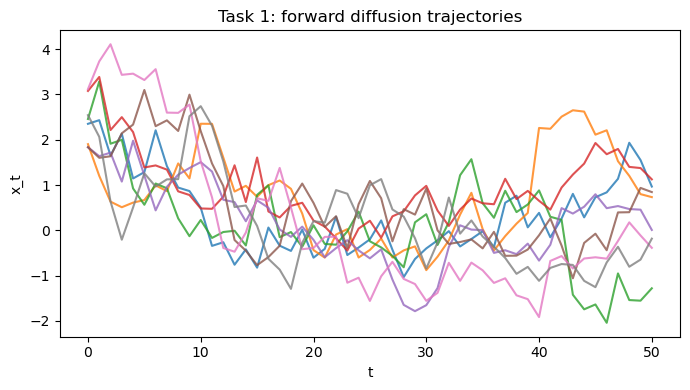

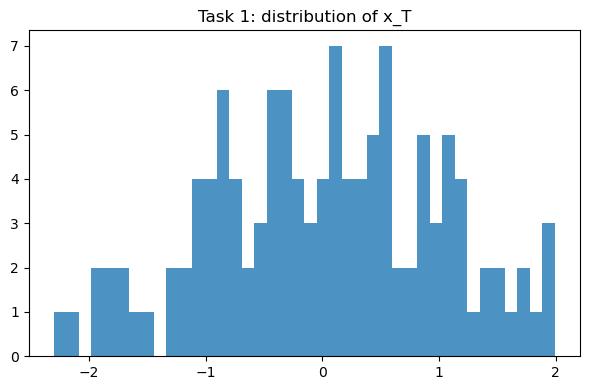

In [13]:
# Task 1 forward experiment
diff1d = Diffusion1D(T=50, schedule="constant", beta_end=0.25)

x0_samples = diff1d.sample_x0(n=120, mean=2.0, var=0.5)

trajectories = [diff1d.run_forward_trajectory(x0_samples[i]) for i in range(8)]
plot_1d_trajectories(
    trajectories,
    save_path="outputs/task1/forward_trajectories.png",
    title="Task 1: forward diffusion trajectories"
)

xt_final = []
for x0 in x0_samples:
    tr = diff1d.run_forward_trajectory(x0)
    xt_final.append(tr[-1])
xt_final = np.array(xt_final)

plot_histogram(
    xt_final,
    save_path="outputs/task1/xt_histogram.png",
    title="Task 1: distribution of x_T"
)

## 4. Task 1: Closed-Form Reverse Process

The next step is to derive the reverse conditional distribution \(q(x_{t-1} \mid x_t, x_0)\). Since the one-dimensional case is analytically tractable, the reverse distribution can be written in closed form as a Gaussian with a time-dependent mean and variance. After deriving this expression, I implement the reverse sampling procedure and use it to generate trajectories from \(x_T\) back to \(x_0\).

This part of the notebook is important because it shows the conceptual foundation of diffusion models. In Task 1, the reverse transition is available analytically, whereas in Task 2 it must be approximated by a neural network.

In [14]:
# Task 1 reverse process placeholder
def reverse_step_closed_form(x_t, x0, t, diff):
    beta_t = diff.betas[t]
    alpha_t = diff.alphas[t]
    alpha_bar_t = diff.alpha_bars[t]
    alpha_bar_prev = 1.0 if t == 0 else diff.alpha_bars[t - 1]

    # Replace this with your exact derived mean and variance:
    mean = (
        np.sqrt(alpha_bar_prev) * beta_t / (1.0 - alpha_bar_t) * x0
        + np.sqrt(alpha_t) * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t) * x_t
    )
    var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)

    x_prev = mean if t == 0 else mean + np.sqrt(var) * np.random.randn(*np.shape(x_t))
    return x_prev

## 5. Task 1: Reverse Process Results

I now visualize the reverse trajectories and compare the recovered samples with the original distribution of \(x_0\). If the implementation is correct, the reverse samples should follow the same overall distribution as the chosen initial Gaussian. This provides an end-to-end verification of the analytical forward and reverse processes in the one-dimensional setting.

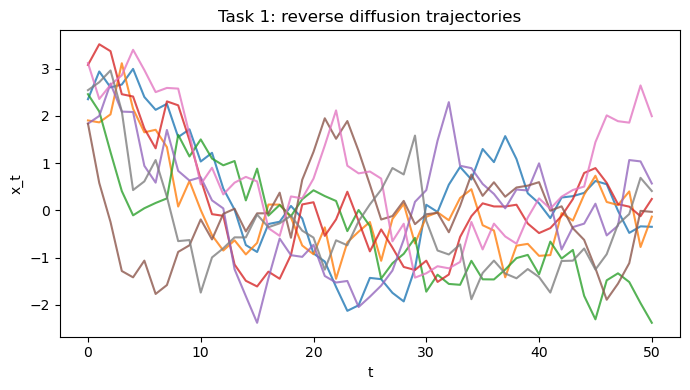

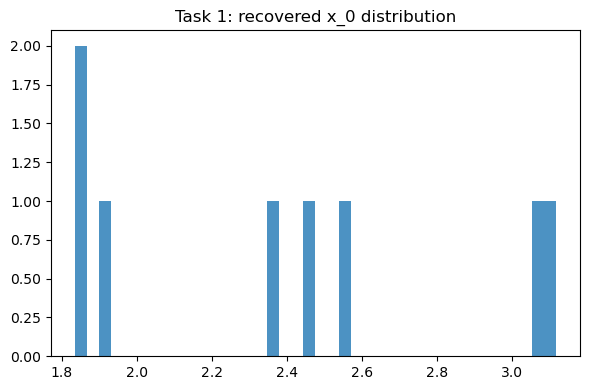

In [15]:
# Task 1 reverse experiment
reverse_trajectories = []
recovered_x0 = []

for i in range(8):
    x0 = x0_samples[i]
    x_t = np.random.randn()
    traj = [x_t]
    x = x_t
    for t in reversed(range(diff1d.T)):
        x = reverse_step_closed_form(x, x0, t, diff1d)
        traj.append(x)
    traj = traj[::-1]
    reverse_trajectories.append(np.array(traj))
    recovered_x0.append(traj[0])

plot_1d_trajectories(
    reverse_trajectories,
    save_path="outputs/task1/reverse_trajectories.png",
    title="Task 1: reverse diffusion trajectories"
)

plot_histogram(
    np.array(recovered_x0),
    save_path="outputs/task1/recovered_x0_histogram.png",
    title="Task 1: recovered x_0 distribution"
)

## 6. Task 2: Two-Dimensional Point Generation

The second mandatory task focuses on learning a reverse diffusion process with a neural network. The goal is to generate two-dimensional point clouds corresponding to three training shapes: a circle, a square, and a dinosaur head. A separate model is trained for each shape.

During training, the network receives a noisy point \(x_t\) together with the diffusion step \(t\), and it predicts the Gaussian noise that was added to the clean point \(x_0\). The model is trained by minimizing the mean squared error between the true noise and the predicted noise. During inference, new samples are generated by starting from a standard Gaussian point cloud and repeatedly applying the learned reverse transitions.

## 7. Dataset Inspection

Before training the diffusion models, I visualize the training point clouds for the three shapes. This provides a simple sanity check for data loading, coordinate ranges, and normalization. It also gives a useful reference for later qualitative comparison with generated samples.

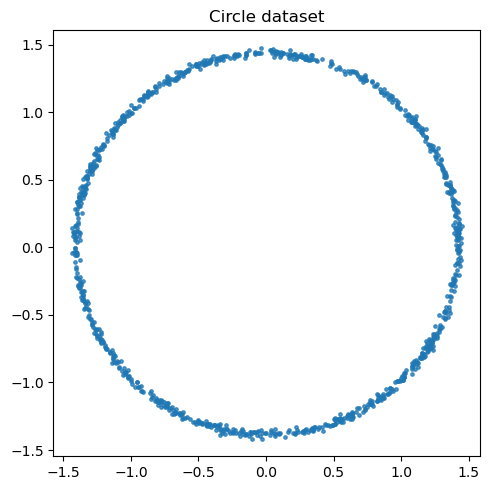

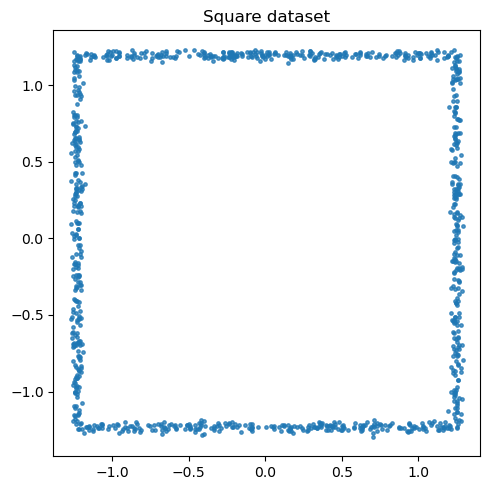

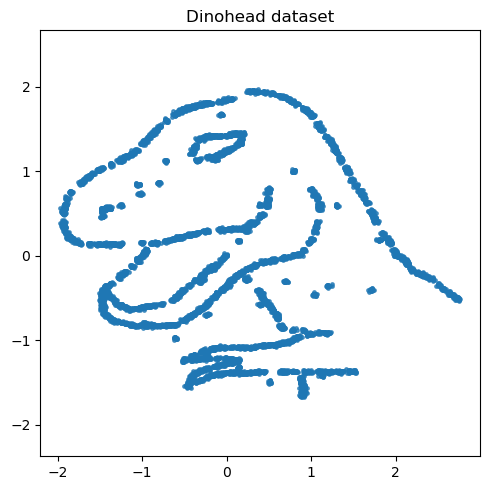

In [23]:
#Task 2 cell Load 2D datasets
class PointDataset(Dataset):
    def __init__(self, npy_path, normalize=True):
        points = np.load(npy_path).astype(np.float32)
        self.raw_mean = points.mean(axis=0, keepdims=True)
        self.raw_std = points.std(axis=0, keepdims=True) + 1e-8

        if normalize:
            points = (points - self.raw_mean) / self.raw_std

        self.points = torch.from_numpy(points)
        self.normalize = normalize

    def __len__(self):
        return len(self.points)

    def __getitem__(self, idx):
        return self.points[idx]

circle_ds = PointDataset("../data/MandatoryTask2/circle_pts.npy")
square_ds = PointDataset("../data/MandatoryTask2/square_pts.npy")
dino_ds = PointDataset("../data/MandatoryTask2/dinohead_pts.npy")

plot_points(circle_ds.points, title="Circle dataset")
plot_points(square_ds.points, title="Square dataset")
plot_points(dino_ds.points, title="Dinohead dataset")

## 8. Model Architecture

For the denoising model, I use a multilayer perceptron with sinusoidal embeddings. Instead of feeding the raw coordinates and timestep directly into the network, I transform them using high-frequency sinusoidal features. This gives the model a richer representation of position and time and is well suited to the diffusion setting.

The final input to the network is formed by concatenating the embeddings of the two spatial coordinates and the embedding of the timestep. The network then predicts a two-dimensional noise vector. A relatively small architecture is sufficient for this task, so I use a compact MLP with a few hidden layers and SiLU nonlinearities.

In [24]:
# Sinusoidal embeddings and MLP
class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        if dim % 2 != 0:
            raise ValueError("Embedding dimension must be even.")

    def forward(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(-1)
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half_dim, device=x.device).float() / max(half_dim - 1, 1)
        )
        angles = x * freqs.unsqueeze(0)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)

class NoisePredictorMLP(nn.Module):
    def __init__(self, coord_emb_dim=64, time_emb_dim=64, hidden_dim=128, num_hidden_layers=3):
        super().__init__()
        self.x_embed = SinusoidalEmbedding(coord_emb_dim)
        self.y_embed = SinusoidalEmbedding(coord_emb_dim)
        self.t_embed = SinusoidalEmbedding(time_emb_dim)

        in_dim = coord_emb_dim + coord_emb_dim + time_emb_dim
        layers = [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers += [nn.Linear(hidden_dim, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, x_t, t):
        x_emb = self.x_embed(x_t[:, 0:1])
        y_emb = self.y_embed(x_t[:, 1:2])
        t_emb = self.t_embed(t.float().unsqueeze(-1))
        h = torch.cat([x_emb, y_emb, t_emb], dim=-1)
        return self.net(h)

## 9. Diffusion Utilities

This section implements the forward noising process and the learned reverse sampling process for the two-dimensional case. The forward process is defined by a variance schedule over \(T\) steps. Given a clean point \(x_0\), a randomly selected timestep \(t\), and Gaussian noise, I construct the corresponding noisy observation \(x_t\).

For reverse sampling, the model predicts the noise component at each step. This predicted noise is then used to estimate the denoised point and to move one step backward in the diffusion chain. Repeating this procedure from \(x_T \sim \mathcal{N}(0, I)\) produces new generated samples.

In [25]:
# 2D diffusion class
def make_beta_schedule_torch(T, schedule="linear", beta_start=1e-4, beta_end=2e-2):
    if schedule == "linear":
        return torch.linspace(beta_start, beta_end, T)
    elif schedule == "quadratic":
        return torch.linspace(beta_start**0.5, beta_end**0.5, T) ** 2
    elif schedule == "constant":
        return torch.full((T,), beta_end)
    else:
        raise ValueError("Unknown schedule.")

class Diffusion2D:
    def __init__(self, T=50, schedule="linear", beta_start=1e-4, beta_end=2e-2, device="cuda"):
        self.T = T
        self.device = device
        self.betas = make_beta_schedule_torch(T, schedule, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - self.alpha_bars)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        x_t = self.sqrt_alpha_bars[t].unsqueeze(-1) * x0 + \
              self.sqrt_one_minus_alpha_bars[t].unsqueeze(-1) * noise
        return x_t, noise

    @torch.no_grad()
    def p_sample(self, model, x_t, t):
        beta_t = self.betas[t].unsqueeze(-1)
        alpha_t = self.alphas[t].unsqueeze(-1)
        alpha_bar_t = self.alpha_bars[t].unsqueeze(-1)

        eps_theta = model(x_t, t)
        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_theta
        )

        if t[0].item() > 0:
            z = torch.randn_like(x_t)
            x_prev = mean + torch.sqrt(beta_t) * z
        else:
            x_prev = mean
        return x_prev

    @torch.no_grad()
    def sample(self, model, n_samples=1024, return_trajectory=False):
        x = torch.randn(n_samples, 2, device=self.device)
        traj = [x.detach().cpu()] if return_trajectory else None
        for step in reversed(range(self.T)):
            t = torch.full((n_samples,), step, device=self.device, dtype=torch.long)
            x = self.p_sample(model, x, t)
            if return_trajectory:
                traj.append(x.detach().cpu())
        return (x.detach().cpu(), traj) if return_trajectory else x.detach().cpu()

## 10. Training Procedure

The training loop follows the standard diffusion objective. At each iteration, I sample a mini-batch of clean points from one shape, draw random timesteps independently for all points in the batch, and sample Gaussian noise. I then generate noisy points \(x_t\) and train the network to predict the exact noise that was used to corrupt the clean data.

The optimizer is Adam, and the loss is mean squared error. To monitor progress, I save training losses and periodically generate samples from the current model. These intermediate outputs are important because the project specifically asks for generated results at different training stages.

In [26]:
# Training function
def train_one_shape(shape_name, dataset, config, output_root="outputs/task2"):
    shape_dir = os.path.join(output_root, shape_name)
    os.makedirs(shape_dir, exist_ok=True)

    loader = DataLoader(dataset, batch_size=config["batch_size"], shuffle=True, drop_last=True)

    model = NoisePredictorMLP(
        coord_emb_dim=config["coord_emb_dim"],
        time_emb_dim=config["time_emb_dim"],
        hidden_dim=config["hidden_dim"],
        num_hidden_layers=config["num_hidden_layers"],
    ).to(device)

    diffusion = Diffusion2D(
        T=config["T"],
        schedule=config["schedule"],
        beta_start=config["beta_start"],
        beta_end=config["beta_end"],
        device=device,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    losses = []
    step = 0

    model.train()
    while step < config["num_steps"]:
        for x0 in loader:
            x0 = x0.to(device)
            bsz = x0.shape[0]

            t = torch.randint(0, config["T"], (bsz,), device=device)
            x_t, noise = diffusion.q_sample(x0, t)
            noise_pred = model(x_t, t)

            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            step += 1

            if step % 100 == 0:
                print(f"{shape_name} | step {step}/{config['num_steps']} | loss {loss.item():.6f}")

            if step % config["save_every"] == 0 or step == 1:
                model.eval()
                samples = diffusion.sample(model, n_samples=config["sample_size"])
                plot_points(
                    samples,
                    save_path=os.path.join(shape_dir, f"samples_step_{step:06d}.png"),
                    title=f"{shape_name} samples at step {step}"
                )
                plot_loss(
                    losses,
                    save_path=os.path.join(shape_dir, "loss_curve.png"),
                    title=f"{shape_name} loss curve"
                )
                model.train()

            if step >= config["num_steps"]:
                break

    torch.save(model.state_dict(), os.path.join(shape_dir, "final_model.pt"))
    with open(os.path.join(shape_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    model.eval()
    final_samples = diffusion.sample(model, n_samples=config["sample_size"])
    plot_points(
        final_samples,
        save_path=os.path.join(shape_dir, "final_samples.png"),
        title=f"{shape_name} final samples"
    )
    plot_loss(
        losses,
        save_path=os.path.join(shape_dir, "loss_curve_final.png"),
        title=f"{shape_name} final loss curve"
    )

    return model, diffusion, losses

### Training the Circle Model

In this experiment, I train a diffusion model only on the circle dataset. This run serves as the simplest case, since the global geometric structure is relatively regular and easy to inspect visually.

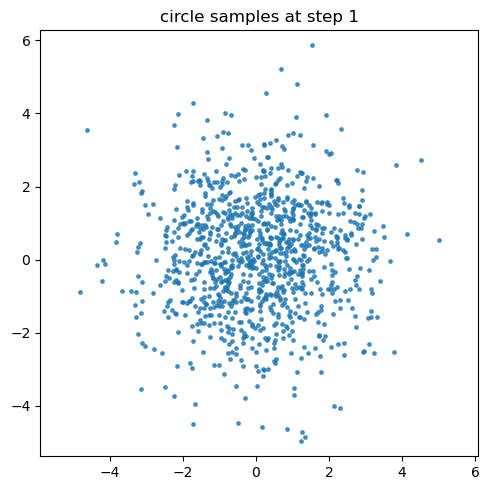

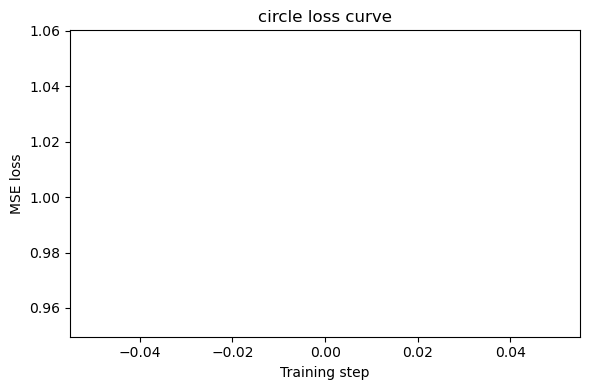

circle | step 100/20000 | loss 0.814823
circle | step 200/20000 | loss 0.694205
circle | step 300/20000 | loss 0.624242
circle | step 400/20000 | loss 0.681921
circle | step 500/20000 | loss 0.610828
circle | step 600/20000 | loss 0.555315
circle | step 700/20000 | loss 0.563055
circle | step 800/20000 | loss 0.597552
circle | step 900/20000 | loss 0.587653
circle | step 1000/20000 | loss 0.624158


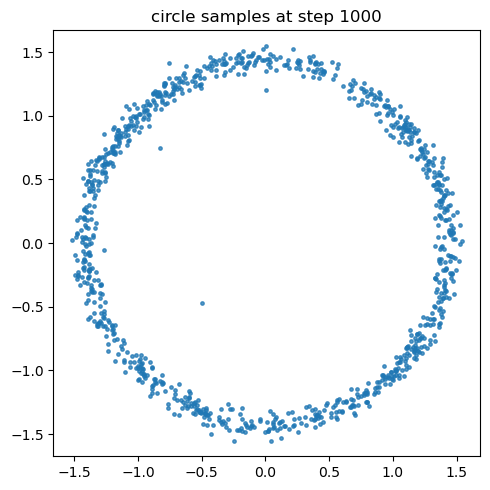

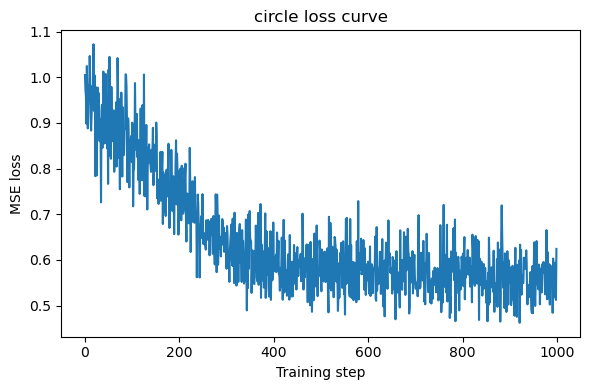

circle | step 1100/20000 | loss 0.524264
circle | step 1200/20000 | loss 0.595755
circle | step 1300/20000 | loss 0.555476
circle | step 1400/20000 | loss 0.615898
circle | step 1500/20000 | loss 0.474363
circle | step 1600/20000 | loss 0.597197
circle | step 1700/20000 | loss 0.503025
circle | step 1800/20000 | loss 0.637434
circle | step 1900/20000 | loss 0.481992
circle | step 2000/20000 | loss 0.565257


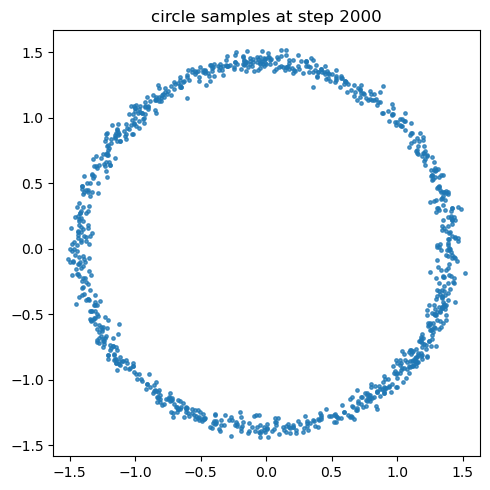

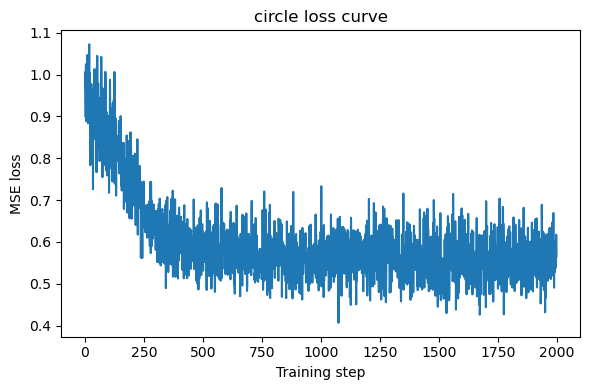

circle | step 2100/20000 | loss 0.638385
circle | step 2200/20000 | loss 0.486279
circle | step 2300/20000 | loss 0.585705
circle | step 2400/20000 | loss 0.514658
circle | step 2500/20000 | loss 0.547252
circle | step 2600/20000 | loss 0.569557
circle | step 2700/20000 | loss 0.475450
circle | step 2800/20000 | loss 0.553524
circle | step 2900/20000 | loss 0.525878
circle | step 3000/20000 | loss 0.677257


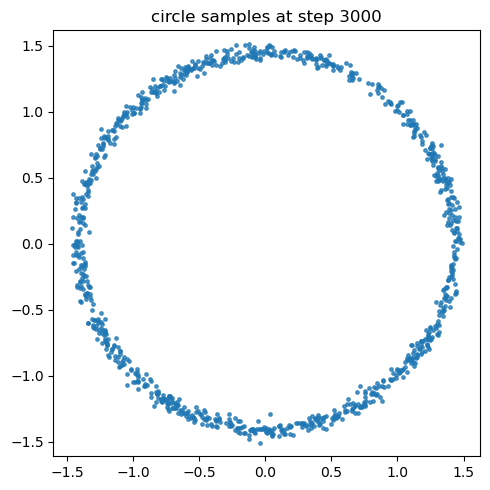

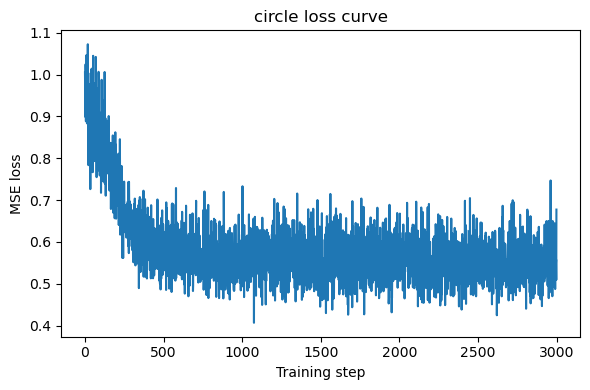

circle | step 3100/20000 | loss 0.600037
circle | step 3200/20000 | loss 0.492108
circle | step 3300/20000 | loss 0.524947
circle | step 3400/20000 | loss 0.513793
circle | step 3500/20000 | loss 0.584496
circle | step 3600/20000 | loss 0.557247
circle | step 3700/20000 | loss 0.583585
circle | step 3800/20000 | loss 0.486061
circle | step 3900/20000 | loss 0.597912
circle | step 4000/20000 | loss 0.618897


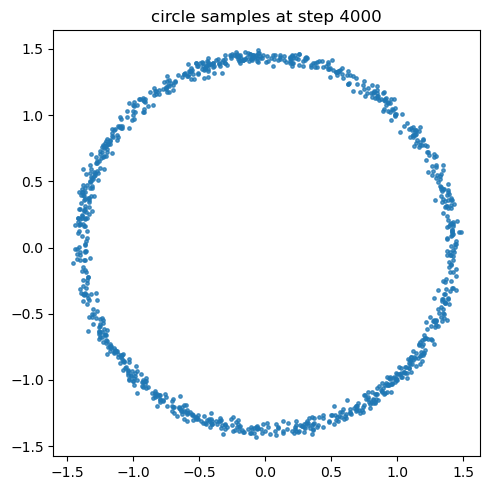

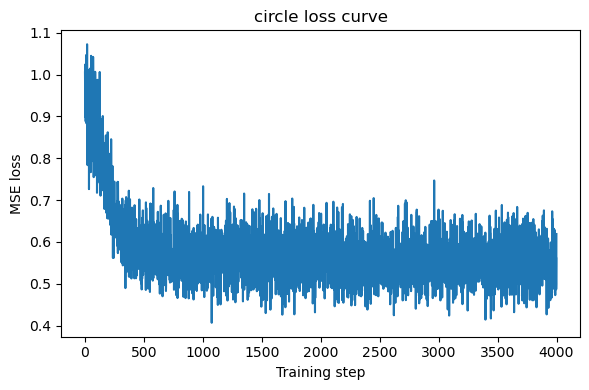

circle | step 4100/20000 | loss 0.617724
circle | step 4200/20000 | loss 0.522650
circle | step 4300/20000 | loss 0.482123
circle | step 4400/20000 | loss 0.531539
circle | step 4500/20000 | loss 0.463592
circle | step 4600/20000 | loss 0.429894
circle | step 4700/20000 | loss 0.552209
circle | step 4800/20000 | loss 0.553640
circle | step 4900/20000 | loss 0.559153
circle | step 5000/20000 | loss 0.555992


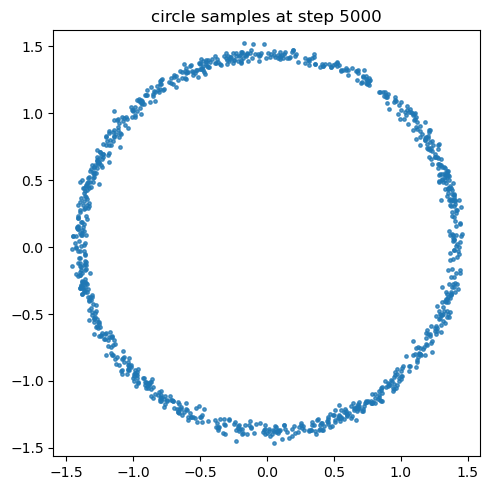

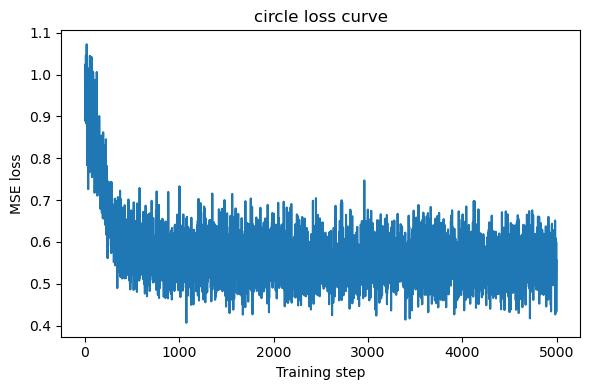

circle | step 5100/20000 | loss 0.565371
circle | step 5200/20000 | loss 0.539039
circle | step 5300/20000 | loss 0.557425
circle | step 5400/20000 | loss 0.607665
circle | step 5500/20000 | loss 0.511146
circle | step 5600/20000 | loss 0.519243
circle | step 5700/20000 | loss 0.493072
circle | step 5800/20000 | loss 0.576917
circle | step 5900/20000 | loss 0.557354
circle | step 6000/20000 | loss 0.567109


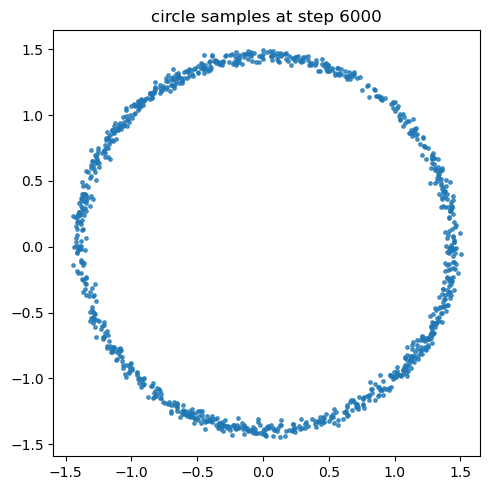

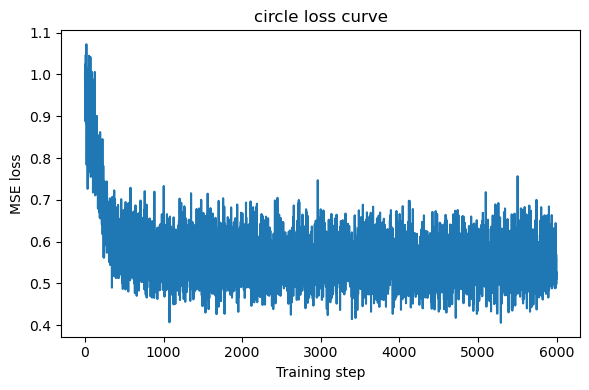

circle | step 6100/20000 | loss 0.570921
circle | step 6200/20000 | loss 0.512234
circle | step 6300/20000 | loss 0.576490
circle | step 6400/20000 | loss 0.489389
circle | step 6500/20000 | loss 0.576165
circle | step 6600/20000 | loss 0.566580
circle | step 6700/20000 | loss 0.559038
circle | step 6800/20000 | loss 0.519002
circle | step 6900/20000 | loss 0.509887
circle | step 7000/20000 | loss 0.654939


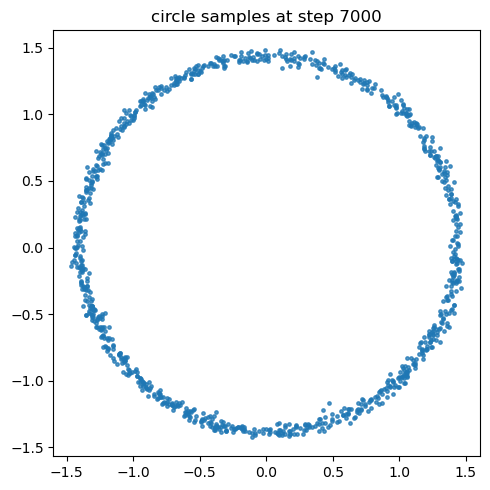

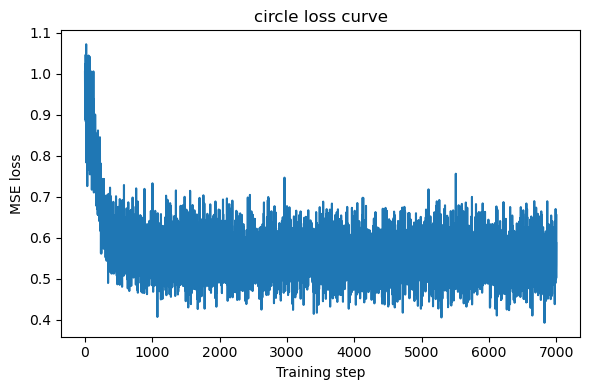

circle | step 7100/20000 | loss 0.540574
circle | step 7200/20000 | loss 0.501055
circle | step 7300/20000 | loss 0.615372
circle | step 7400/20000 | loss 0.532125
circle | step 7500/20000 | loss 0.529375
circle | step 7600/20000 | loss 0.529012
circle | step 7700/20000 | loss 0.480333
circle | step 7800/20000 | loss 0.461317
circle | step 7900/20000 | loss 0.536244
circle | step 8000/20000 | loss 0.573136


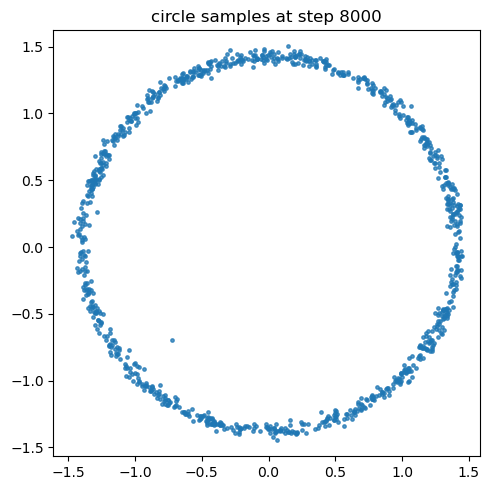

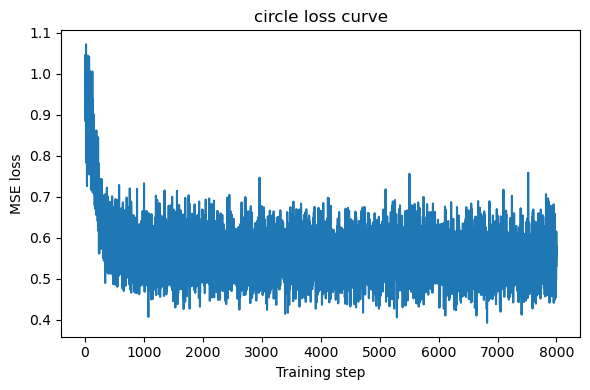

circle | step 8100/20000 | loss 0.548389
circle | step 8200/20000 | loss 0.547203
circle | step 8300/20000 | loss 0.573241
circle | step 8400/20000 | loss 0.574059
circle | step 8500/20000 | loss 0.526719
circle | step 8600/20000 | loss 0.507210
circle | step 8700/20000 | loss 0.467679
circle | step 8800/20000 | loss 0.588092
circle | step 8900/20000 | loss 0.612412
circle | step 9000/20000 | loss 0.555660


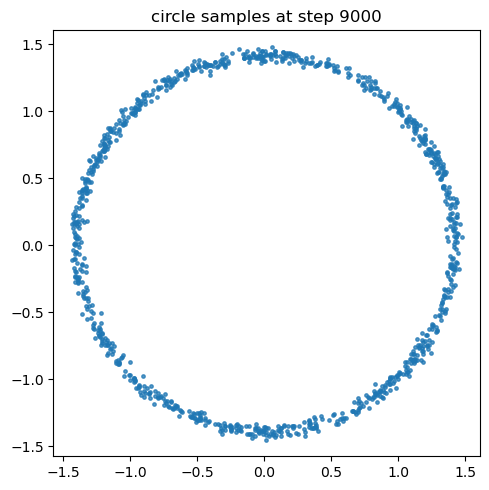

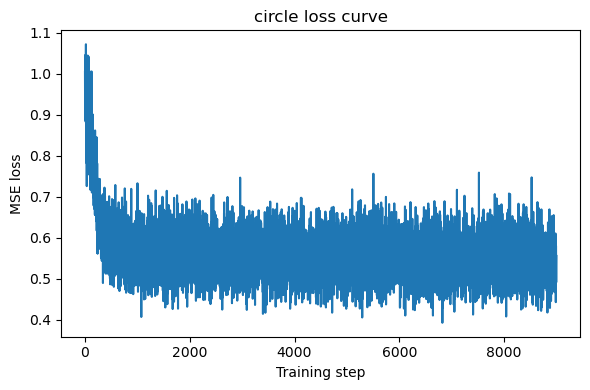

circle | step 9100/20000 | loss 0.489223
circle | step 9200/20000 | loss 0.549716
circle | step 9300/20000 | loss 0.529103
circle | step 9400/20000 | loss 0.530380
circle | step 9500/20000 | loss 0.548517
circle | step 9600/20000 | loss 0.592470
circle | step 9700/20000 | loss 0.617937
circle | step 9800/20000 | loss 0.513119
circle | step 9900/20000 | loss 0.588019
circle | step 10000/20000 | loss 0.506697


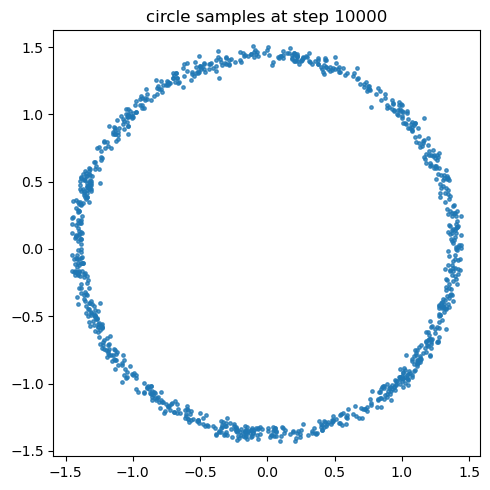

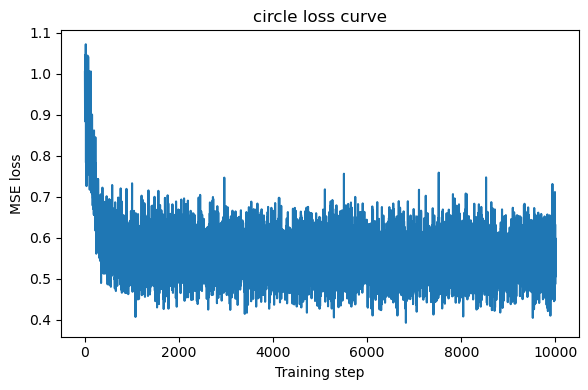

circle | step 10100/20000 | loss 0.598421
circle | step 10200/20000 | loss 0.549174
circle | step 10300/20000 | loss 0.585912
circle | step 10400/20000 | loss 0.482808
circle | step 10500/20000 | loss 0.531555
circle | step 10600/20000 | loss 0.584962
circle | step 10700/20000 | loss 0.539212
circle | step 10800/20000 | loss 0.533811
circle | step 10900/20000 | loss 0.488881
circle | step 11000/20000 | loss 0.621175


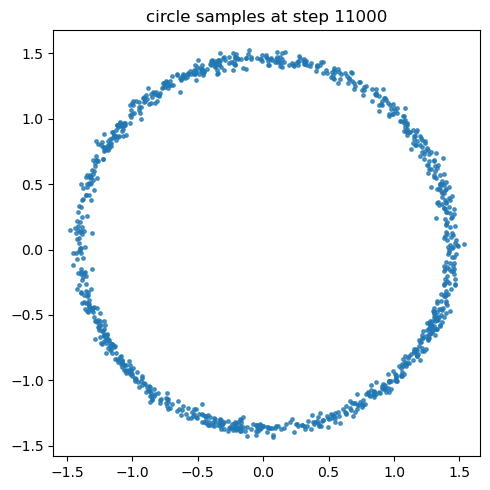

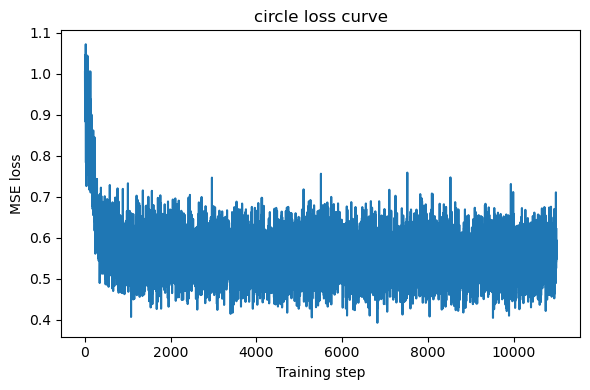

circle | step 11100/20000 | loss 0.549664
circle | step 11200/20000 | loss 0.487366
circle | step 11300/20000 | loss 0.585598
circle | step 11400/20000 | loss 0.563085
circle | step 11500/20000 | loss 0.514537
circle | step 11600/20000 | loss 0.536323
circle | step 11700/20000 | loss 0.477960
circle | step 11800/20000 | loss 0.546941
circle | step 11900/20000 | loss 0.471202
circle | step 12000/20000 | loss 0.488330


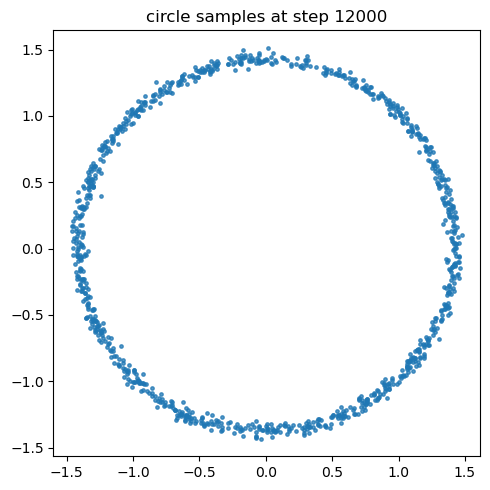

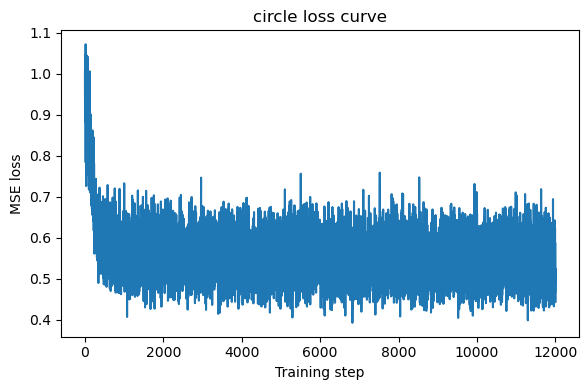

circle | step 12100/20000 | loss 0.506460
circle | step 12200/20000 | loss 0.590099
circle | step 12300/20000 | loss 0.546173
circle | step 12400/20000 | loss 0.530203
circle | step 12500/20000 | loss 0.501574
circle | step 12600/20000 | loss 0.564164
circle | step 12700/20000 | loss 0.627359
circle | step 12800/20000 | loss 0.562081
circle | step 12900/20000 | loss 0.579239
circle | step 13000/20000 | loss 0.561724


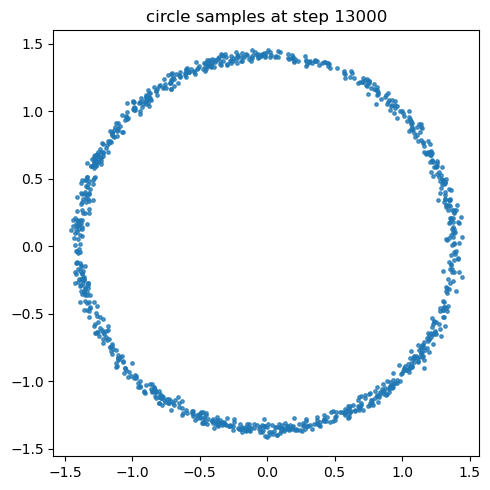

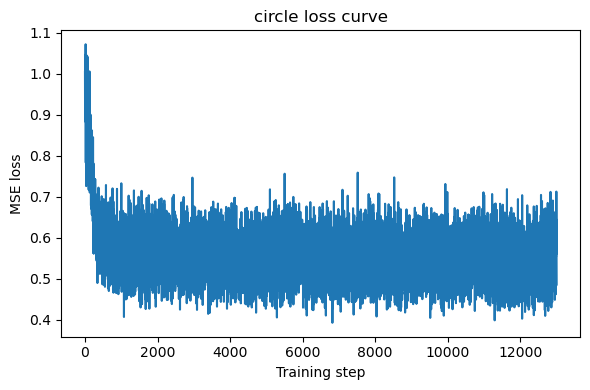

circle | step 13100/20000 | loss 0.554362
circle | step 13200/20000 | loss 0.547424
circle | step 13300/20000 | loss 0.607343
circle | step 13400/20000 | loss 0.585251
circle | step 13500/20000 | loss 0.547898
circle | step 13600/20000 | loss 0.497744
circle | step 13700/20000 | loss 0.548668
circle | step 13800/20000 | loss 0.509529
circle | step 13900/20000 | loss 0.559299
circle | step 14000/20000 | loss 0.595049


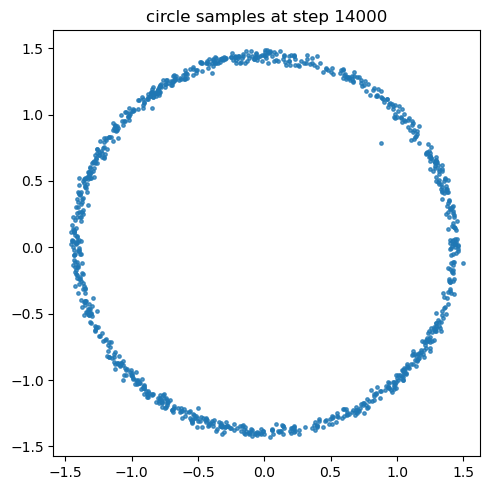

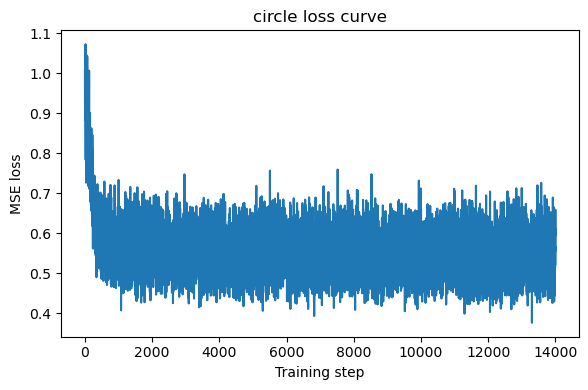

circle | step 14100/20000 | loss 0.559775
circle | step 14200/20000 | loss 0.528156
circle | step 14300/20000 | loss 0.586651
circle | step 14400/20000 | loss 0.592088
circle | step 14500/20000 | loss 0.520114
circle | step 14600/20000 | loss 0.536325
circle | step 14700/20000 | loss 0.507295
circle | step 14800/20000 | loss 0.574443
circle | step 14900/20000 | loss 0.572811
circle | step 15000/20000 | loss 0.538070


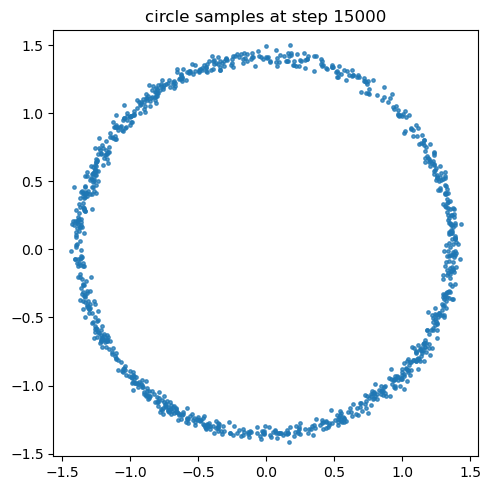

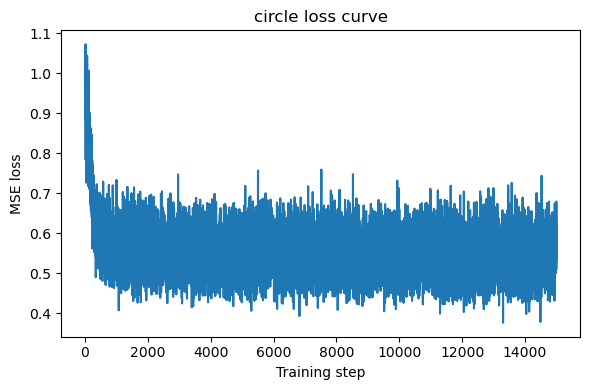

circle | step 15100/20000 | loss 0.579062
circle | step 15200/20000 | loss 0.513078
circle | step 15300/20000 | loss 0.528456
circle | step 15400/20000 | loss 0.577493
circle | step 15500/20000 | loss 0.515085
circle | step 15600/20000 | loss 0.519973
circle | step 15700/20000 | loss 0.557259
circle | step 15800/20000 | loss 0.532111
circle | step 15900/20000 | loss 0.581956
circle | step 16000/20000 | loss 0.566718


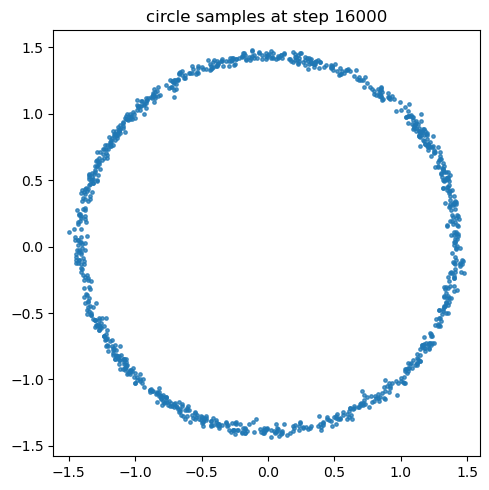

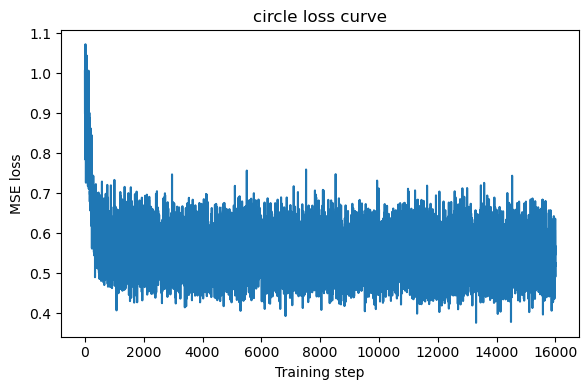

circle | step 16100/20000 | loss 0.540280
circle | step 16200/20000 | loss 0.514026
circle | step 16300/20000 | loss 0.479741
circle | step 16400/20000 | loss 0.709839
circle | step 16500/20000 | loss 0.583627
circle | step 16600/20000 | loss 0.507016
circle | step 16700/20000 | loss 0.546486
circle | step 16800/20000 | loss 0.484273
circle | step 16900/20000 | loss 0.508936
circle | step 17000/20000 | loss 0.542148


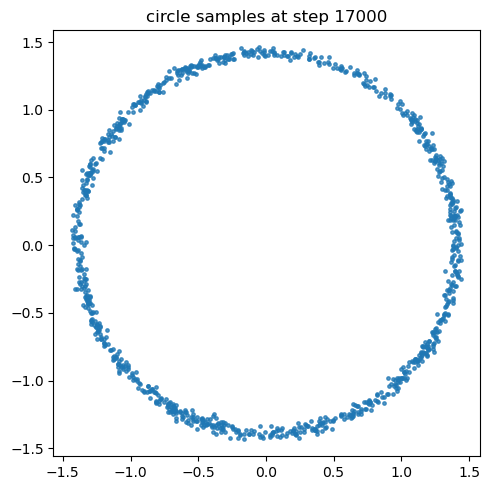

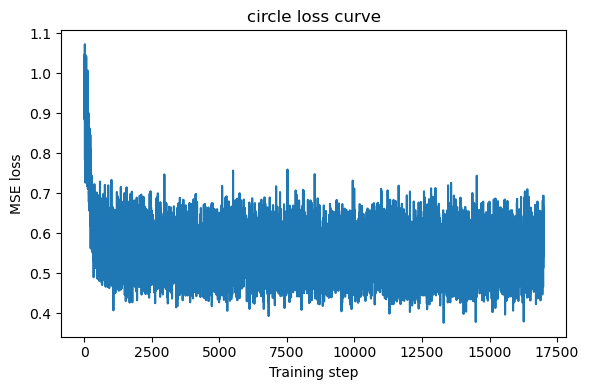

circle | step 17100/20000 | loss 0.523821
circle | step 17200/20000 | loss 0.551965
circle | step 17300/20000 | loss 0.530071
circle | step 17400/20000 | loss 0.583383
circle | step 17500/20000 | loss 0.527189
circle | step 17600/20000 | loss 0.537419
circle | step 17700/20000 | loss 0.580108
circle | step 17800/20000 | loss 0.598163
circle | step 17900/20000 | loss 0.541494
circle | step 18000/20000 | loss 0.499181


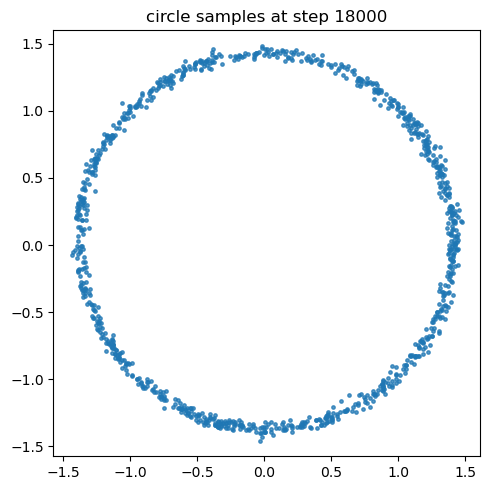

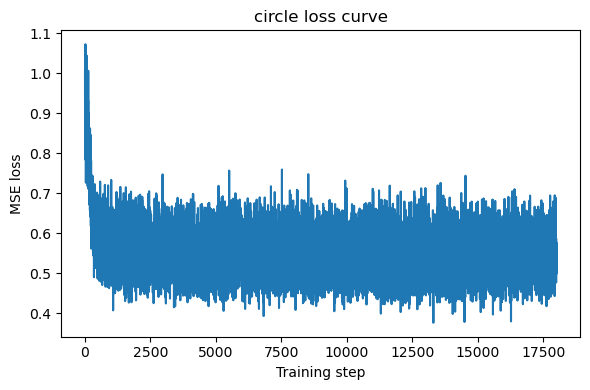

circle | step 18100/20000 | loss 0.496580
circle | step 18200/20000 | loss 0.559130
circle | step 18300/20000 | loss 0.569185
circle | step 18400/20000 | loss 0.531898
circle | step 18500/20000 | loss 0.580152
circle | step 18600/20000 | loss 0.573874
circle | step 18700/20000 | loss 0.489398
circle | step 18800/20000 | loss 0.559389
circle | step 18900/20000 | loss 0.478908
circle | step 19000/20000 | loss 0.560888


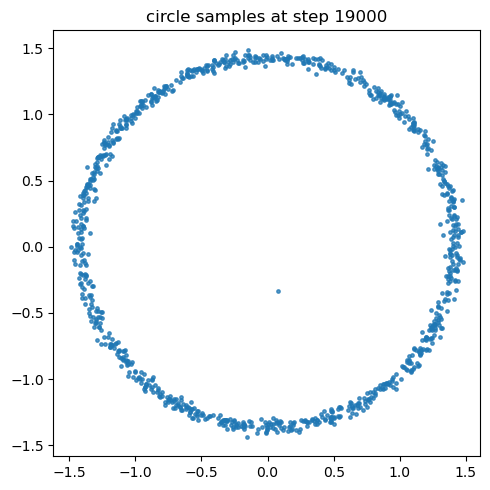

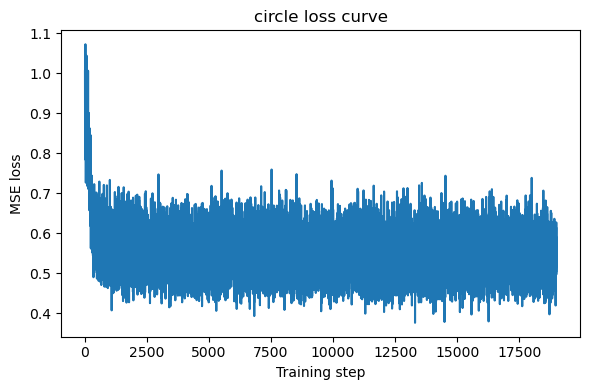

circle | step 19100/20000 | loss 0.562285
circle | step 19200/20000 | loss 0.491150
circle | step 19300/20000 | loss 0.526630
circle | step 19400/20000 | loss 0.533609
circle | step 19500/20000 | loss 0.498697
circle | step 19600/20000 | loss 0.486982
circle | step 19700/20000 | loss 0.445139
circle | step 19800/20000 | loss 0.581565
circle | step 19900/20000 | loss 0.498984
circle | step 20000/20000 | loss 0.557645


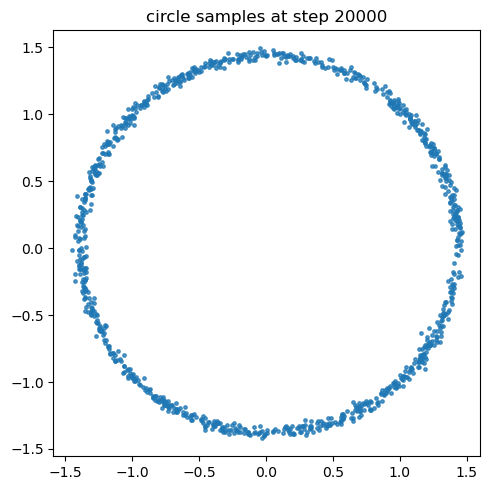

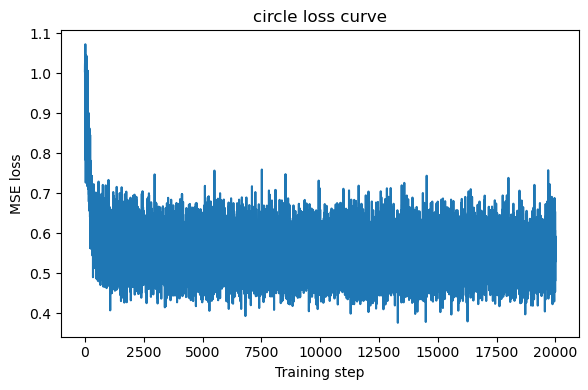

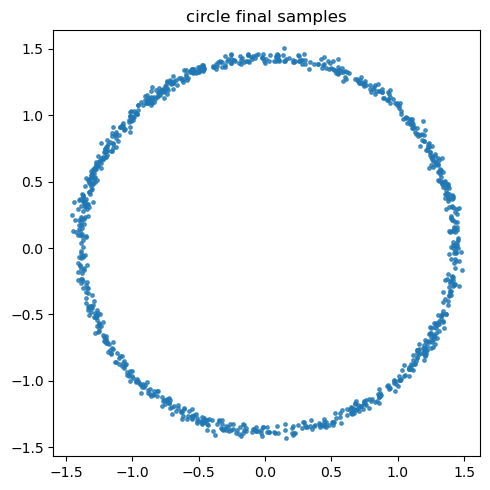

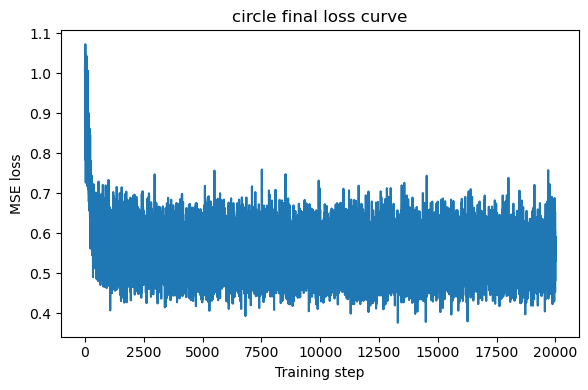

In [27]:
# Train 
circle_model, circle_diffusion, circle_losses = train_one_shape(
    "circle",
    circle_ds,
    CONFIG,
)

### Training the Square Model

I now repeat the same procedure for the square dataset. Compared with the circle, this shape is more challenging because the corners represent localized high-curvature regions that are often harder to reproduce accurately.

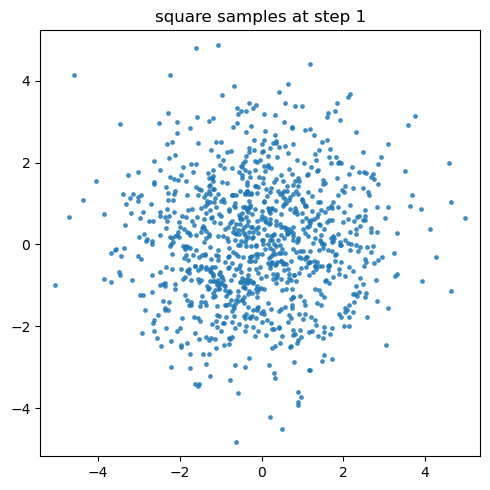

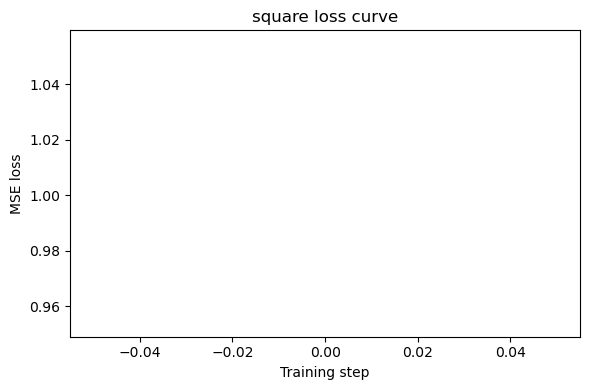

square | step 100/20000 | loss 0.877408
square | step 200/20000 | loss 0.748524
square | step 300/20000 | loss 0.693819
square | step 400/20000 | loss 0.646900
square | step 500/20000 | loss 0.650154
square | step 600/20000 | loss 0.570062
square | step 700/20000 | loss 0.610145
square | step 800/20000 | loss 0.606208
square | step 900/20000 | loss 0.680854
square | step 1000/20000 | loss 0.478596


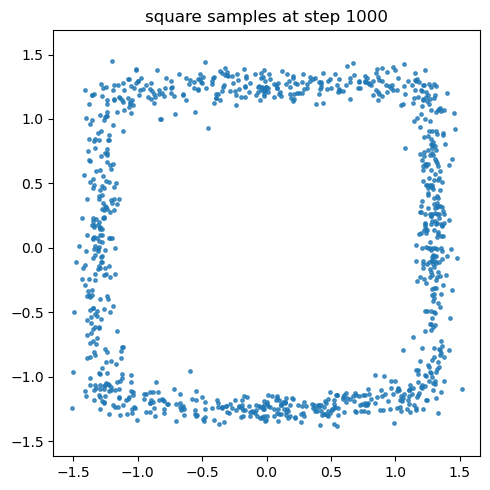

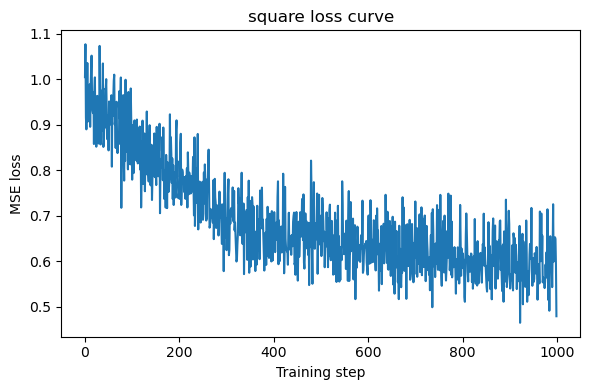

square | step 1100/20000 | loss 0.586100
square | step 1200/20000 | loss 0.579878
square | step 1300/20000 | loss 0.585294
square | step 1400/20000 | loss 0.524106
square | step 1500/20000 | loss 0.567635
square | step 1600/20000 | loss 0.518648
square | step 1700/20000 | loss 0.525115
square | step 1800/20000 | loss 0.648352
square | step 1900/20000 | loss 0.614124
square | step 2000/20000 | loss 0.614831


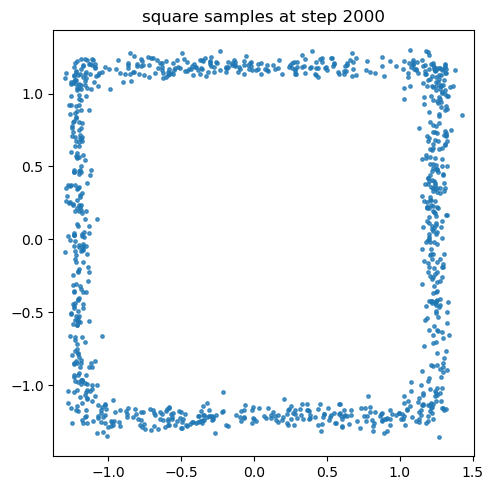

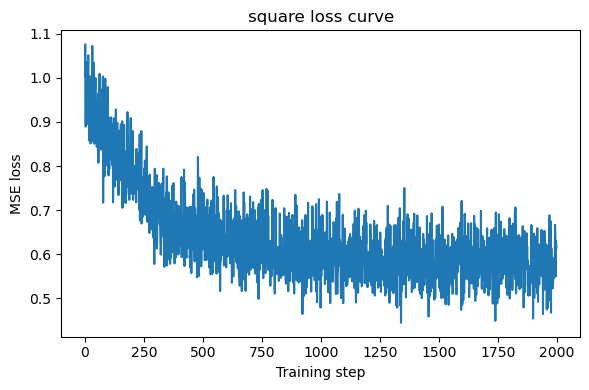

square | step 2100/20000 | loss 0.500965
square | step 2200/20000 | loss 0.540965
square | step 2300/20000 | loss 0.672750
square | step 2400/20000 | loss 0.613769
square | step 2500/20000 | loss 0.563420
square | step 2600/20000 | loss 0.613955
square | step 2700/20000 | loss 0.609641
square | step 2800/20000 | loss 0.541030
square | step 2900/20000 | loss 0.520339
square | step 3000/20000 | loss 0.581365


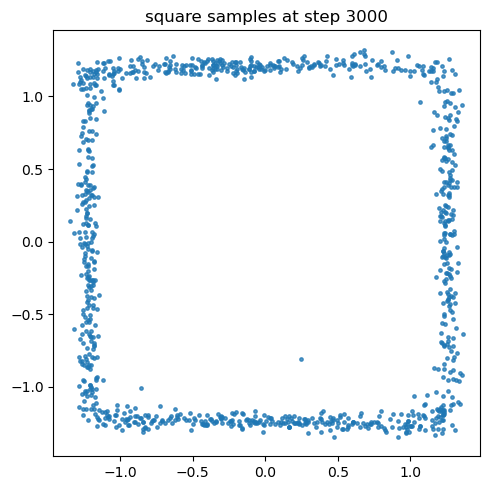

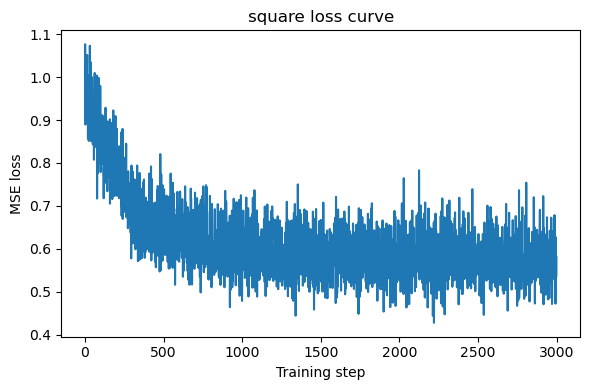

square | step 3100/20000 | loss 0.545868
square | step 3200/20000 | loss 0.629693
square | step 3300/20000 | loss 0.678157
square | step 3400/20000 | loss 0.553183
square | step 3500/20000 | loss 0.658040
square | step 3600/20000 | loss 0.570995
square | step 3700/20000 | loss 0.585141
square | step 3800/20000 | loss 0.592194
square | step 3900/20000 | loss 0.541447
square | step 4000/20000 | loss 0.576643


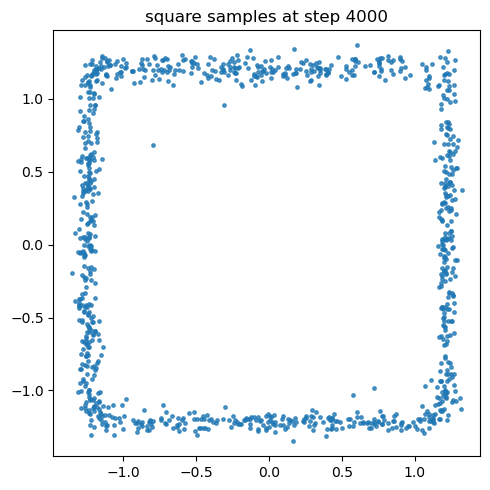

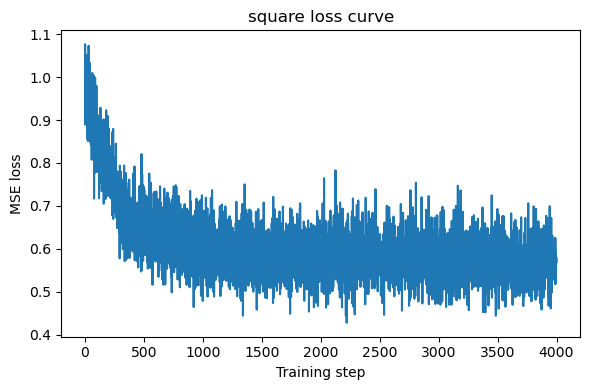

square | step 4100/20000 | loss 0.639678
square | step 4200/20000 | loss 0.556983
square | step 4300/20000 | loss 0.556166
square | step 4400/20000 | loss 0.463440
square | step 4500/20000 | loss 0.530029
square | step 4600/20000 | loss 0.494364
square | step 4700/20000 | loss 0.546974
square | step 4800/20000 | loss 0.531529
square | step 4900/20000 | loss 0.670866
square | step 5000/20000 | loss 0.532079


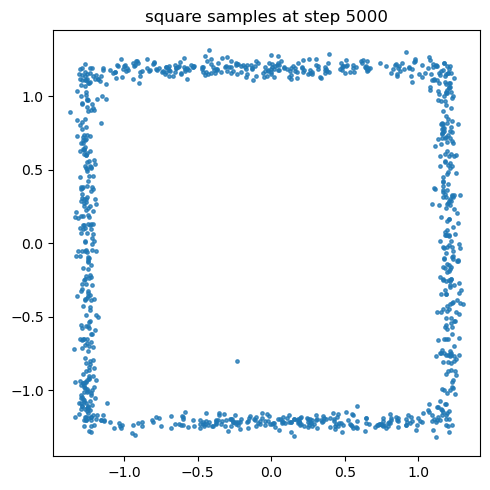

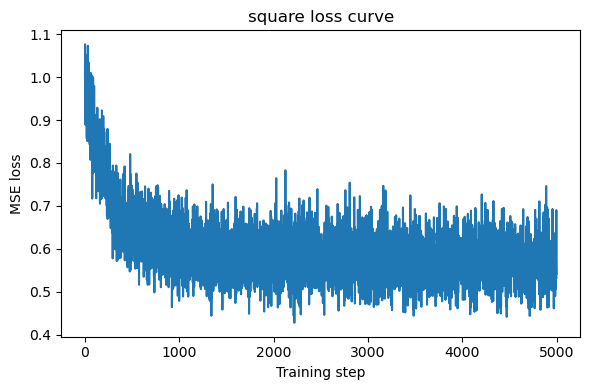

square | step 5100/20000 | loss 0.577811
square | step 5200/20000 | loss 0.563388
square | step 5300/20000 | loss 0.578903
square | step 5400/20000 | loss 0.493222
square | step 5500/20000 | loss 0.583731
square | step 5600/20000 | loss 0.517943
square | step 5700/20000 | loss 0.512434
square | step 5800/20000 | loss 0.604999
square | step 5900/20000 | loss 0.551593
square | step 6000/20000 | loss 0.517927


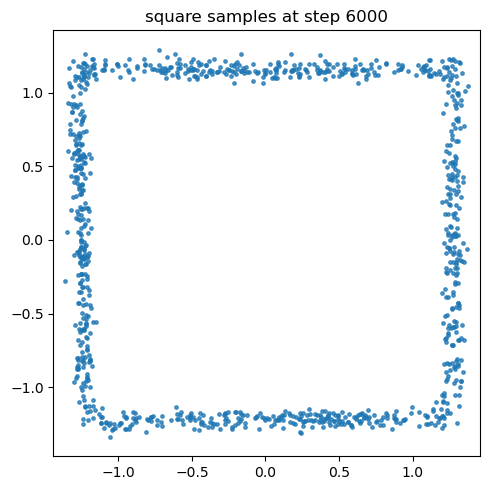

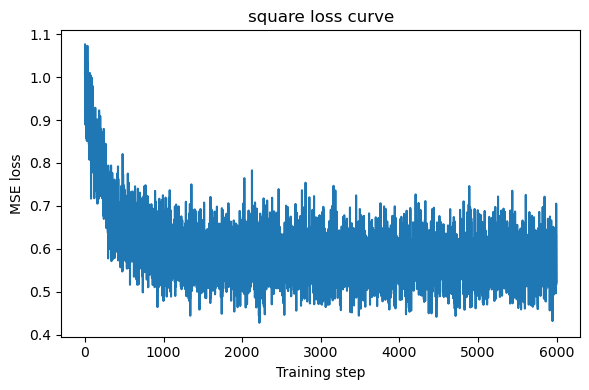

square | step 6100/20000 | loss 0.475553
square | step 6200/20000 | loss 0.553841
square | step 6300/20000 | loss 0.482768
square | step 6400/20000 | loss 0.513667
square | step 6500/20000 | loss 0.601807
square | step 6600/20000 | loss 0.538100
square | step 6700/20000 | loss 0.542941
square | step 6800/20000 | loss 0.593593
square | step 6900/20000 | loss 0.557048
square | step 7000/20000 | loss 0.536750


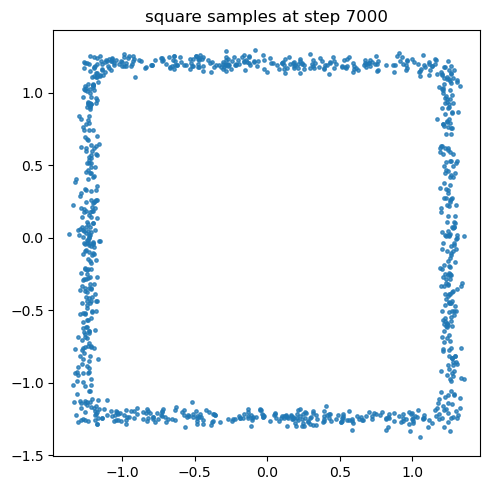

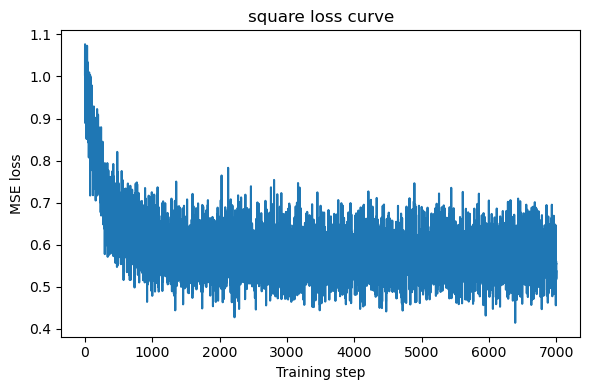

square | step 7100/20000 | loss 0.583518
square | step 7200/20000 | loss 0.490482
square | step 7300/20000 | loss 0.626100
square | step 7400/20000 | loss 0.649495
square | step 7500/20000 | loss 0.540060
square | step 7600/20000 | loss 0.546795
square | step 7700/20000 | loss 0.584818
square | step 7800/20000 | loss 0.571260
square | step 7900/20000 | loss 0.542689
square | step 8000/20000 | loss 0.598191


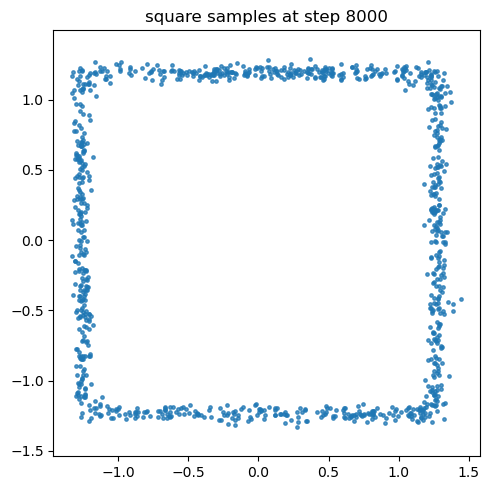

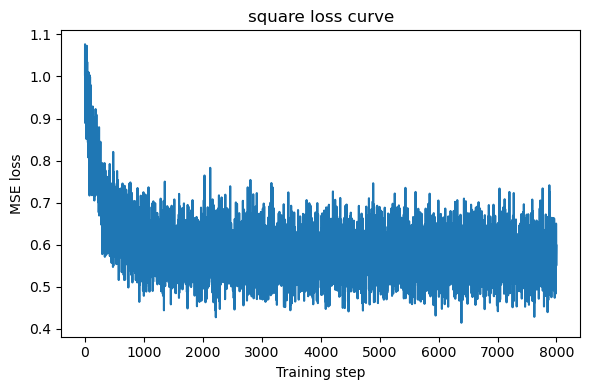

square | step 8100/20000 | loss 0.623096
square | step 8200/20000 | loss 0.582938
square | step 8300/20000 | loss 0.618281
square | step 8400/20000 | loss 0.549366
square | step 8500/20000 | loss 0.593363
square | step 8600/20000 | loss 0.575743
square | step 8700/20000 | loss 0.590599
square | step 8800/20000 | loss 0.535782
square | step 8900/20000 | loss 0.526336
square | step 9000/20000 | loss 0.534575


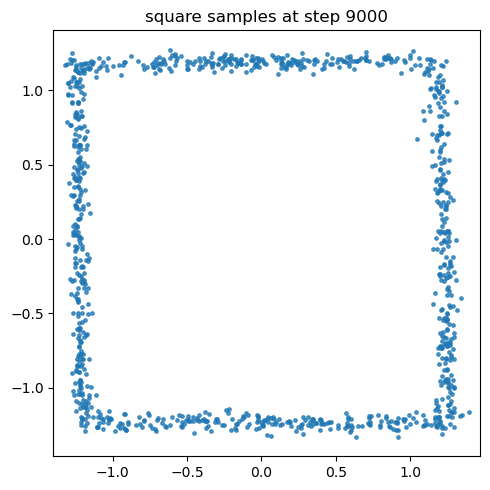

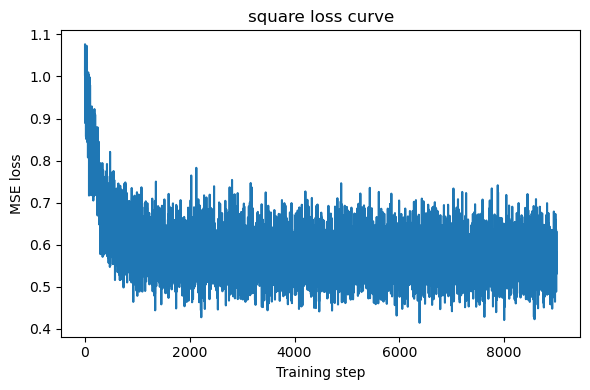

square | step 9100/20000 | loss 0.531224
square | step 9200/20000 | loss 0.614956
square | step 9300/20000 | loss 0.592205
square | step 9400/20000 | loss 0.635795
square | step 9500/20000 | loss 0.531415
square | step 9600/20000 | loss 0.557759
square | step 9700/20000 | loss 0.539067
square | step 9800/20000 | loss 0.576113
square | step 9900/20000 | loss 0.604643
square | step 10000/20000 | loss 0.578797


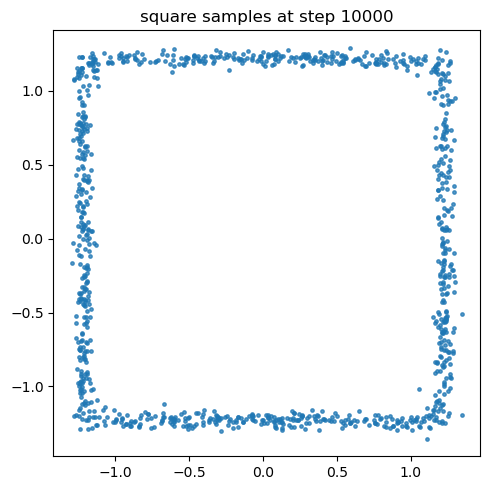

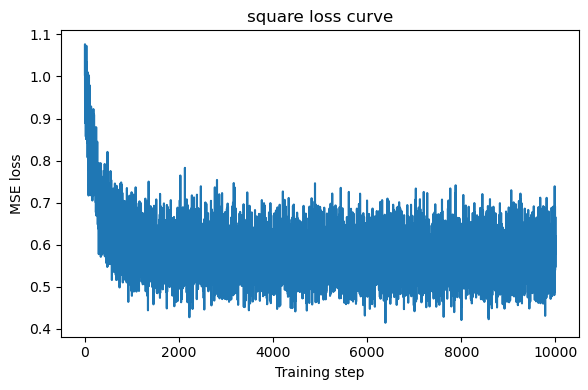

square | step 10100/20000 | loss 0.577241
square | step 10200/20000 | loss 0.530019
square | step 10300/20000 | loss 0.634883
square | step 10400/20000 | loss 0.558127
square | step 10500/20000 | loss 0.669780
square | step 10600/20000 | loss 0.608853
square | step 10700/20000 | loss 0.545540
square | step 10800/20000 | loss 0.606803
square | step 10900/20000 | loss 0.482460
square | step 11000/20000 | loss 0.465709


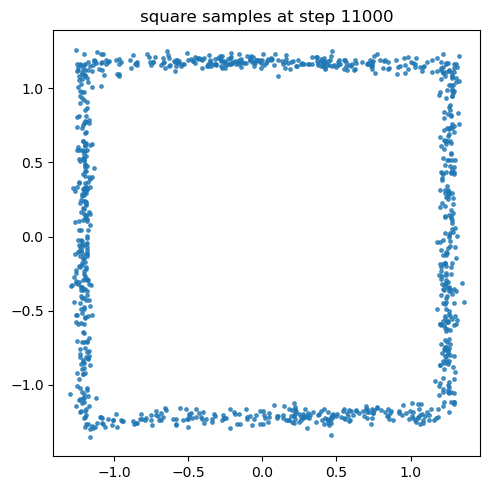

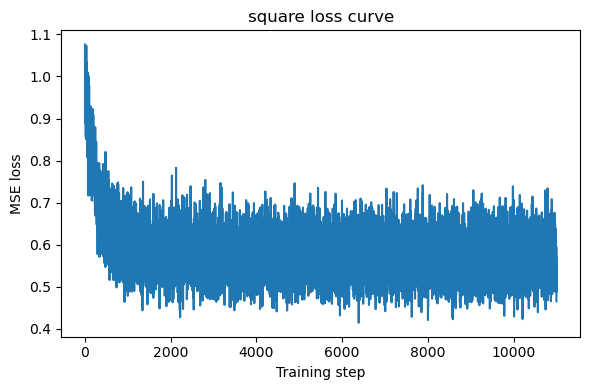

square | step 11100/20000 | loss 0.534754
square | step 11200/20000 | loss 0.504904
square | step 11300/20000 | loss 0.541229
square | step 11400/20000 | loss 0.574743
square | step 11500/20000 | loss 0.626760
square | step 11600/20000 | loss 0.517558
square | step 11700/20000 | loss 0.568709
square | step 11800/20000 | loss 0.579071
square | step 11900/20000 | loss 0.558917
square | step 12000/20000 | loss 0.653942


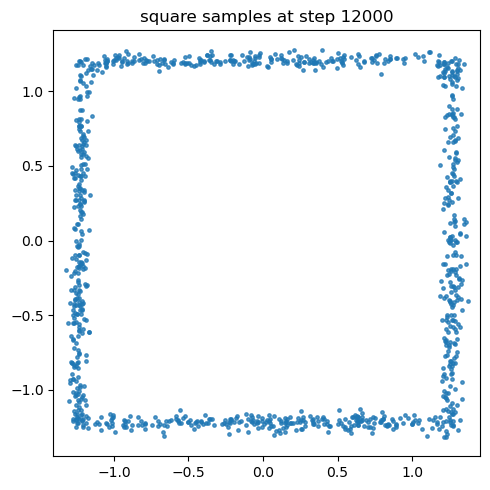

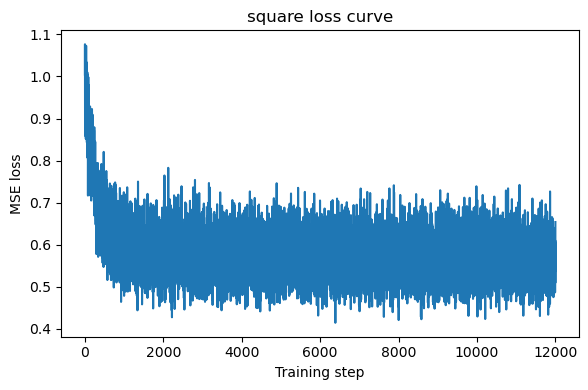

square | step 12100/20000 | loss 0.611513
square | step 12200/20000 | loss 0.622429
square | step 12300/20000 | loss 0.598626
square | step 12400/20000 | loss 0.528801
square | step 12500/20000 | loss 0.608733
square | step 12600/20000 | loss 0.554559
square | step 12700/20000 | loss 0.534661
square | step 12800/20000 | loss 0.575779
square | step 12900/20000 | loss 0.515392
square | step 13000/20000 | loss 0.498837


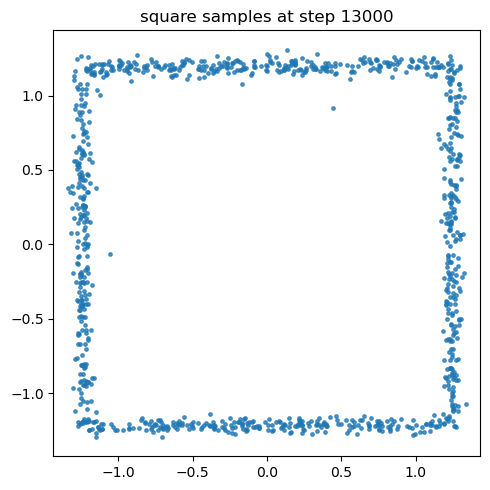

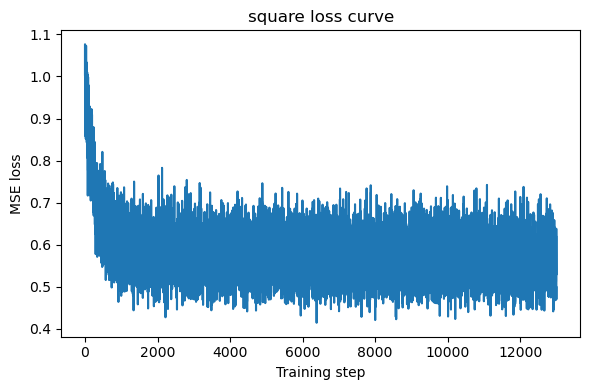

square | step 13100/20000 | loss 0.504979
square | step 13200/20000 | loss 0.576444
square | step 13300/20000 | loss 0.466573
square | step 13400/20000 | loss 0.643030
square | step 13500/20000 | loss 0.577235
square | step 13600/20000 | loss 0.650580
square | step 13700/20000 | loss 0.526232
square | step 13800/20000 | loss 0.637163
square | step 13900/20000 | loss 0.545162
square | step 14000/20000 | loss 0.529314


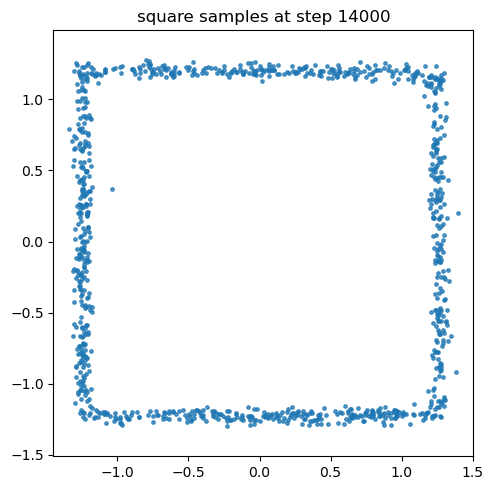

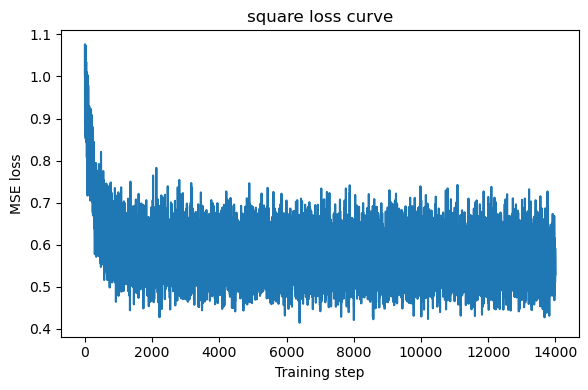

square | step 14100/20000 | loss 0.598881
square | step 14200/20000 | loss 0.500509
square | step 14300/20000 | loss 0.637298
square | step 14400/20000 | loss 0.477479
square | step 14500/20000 | loss 0.618594
square | step 14600/20000 | loss 0.576573
square | step 14700/20000 | loss 0.614440
square | step 14800/20000 | loss 0.556670
square | step 14900/20000 | loss 0.556580
square | step 15000/20000 | loss 0.522490


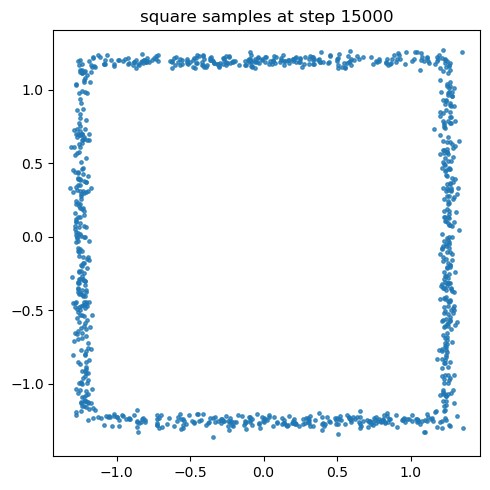

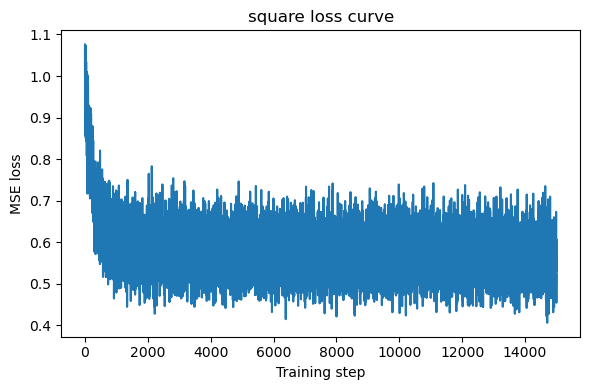

square | step 15100/20000 | loss 0.546158
square | step 15200/20000 | loss 0.527065
square | step 15300/20000 | loss 0.586230
square | step 15400/20000 | loss 0.585513
square | step 15500/20000 | loss 0.555903
square | step 15600/20000 | loss 0.572756
square | step 15700/20000 | loss 0.513896
square | step 15800/20000 | loss 0.603333
square | step 15900/20000 | loss 0.605277
square | step 16000/20000 | loss 0.669716


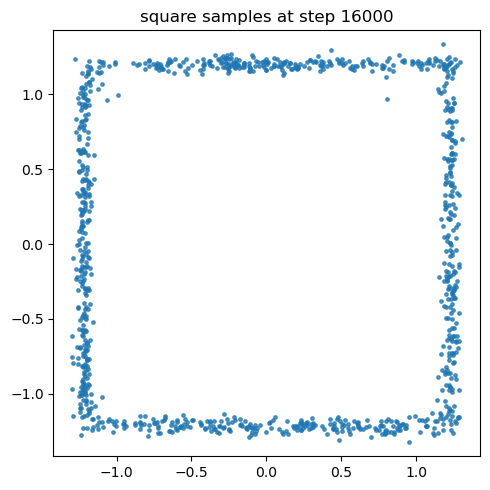

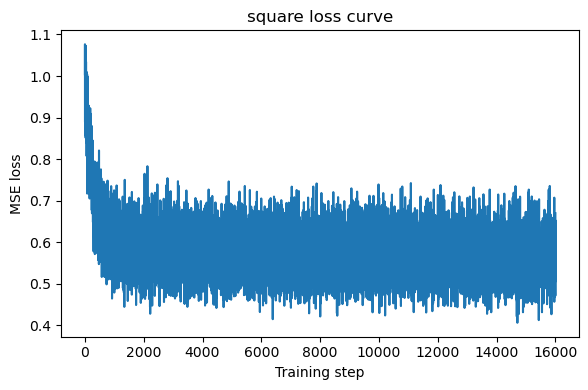

square | step 16100/20000 | loss 0.532502
square | step 16200/20000 | loss 0.576515
square | step 16300/20000 | loss 0.598690
square | step 16400/20000 | loss 0.593994
square | step 16500/20000 | loss 0.579006
square | step 16600/20000 | loss 0.593062
square | step 16700/20000 | loss 0.493340
square | step 16800/20000 | loss 0.646664
square | step 16900/20000 | loss 0.550811
square | step 17000/20000 | loss 0.535191


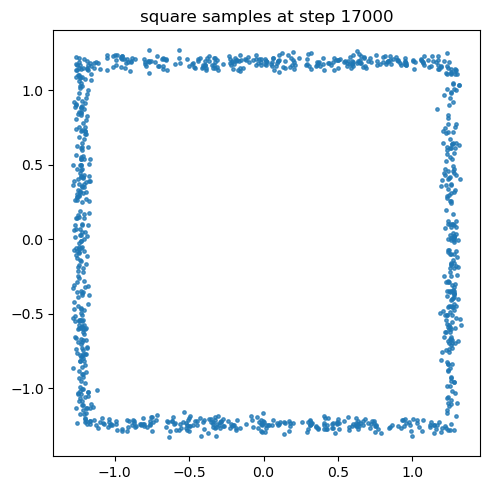

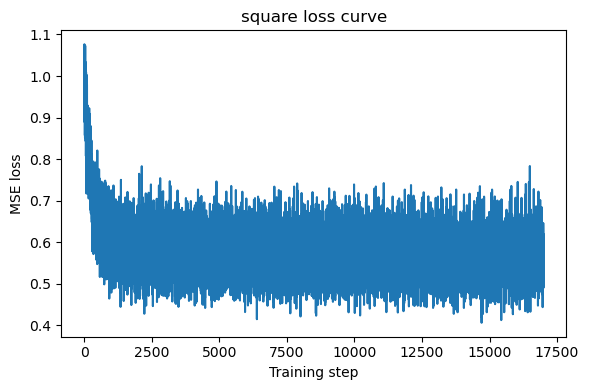

square | step 17100/20000 | loss 0.624030
square | step 17200/20000 | loss 0.586419
square | step 17300/20000 | loss 0.420654
square | step 17400/20000 | loss 0.592959
square | step 17500/20000 | loss 0.689415
square | step 17600/20000 | loss 0.649235
square | step 17700/20000 | loss 0.586579
square | step 17800/20000 | loss 0.579224
square | step 17900/20000 | loss 0.606649
square | step 18000/20000 | loss 0.541380


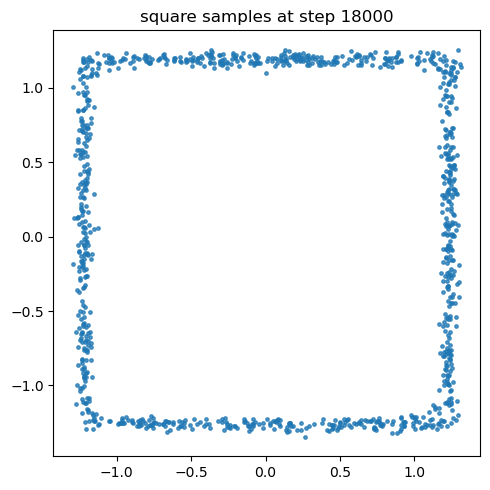

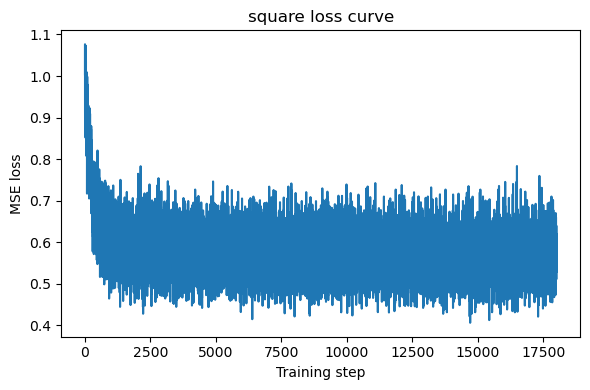

square | step 18100/20000 | loss 0.523853
square | step 18200/20000 | loss 0.538300
square | step 18300/20000 | loss 0.500408
square | step 18400/20000 | loss 0.564642
square | step 18500/20000 | loss 0.574392
square | step 18600/20000 | loss 0.557488
square | step 18700/20000 | loss 0.558383
square | step 18800/20000 | loss 0.575296
square | step 18900/20000 | loss 0.460239
square | step 19000/20000 | loss 0.498394


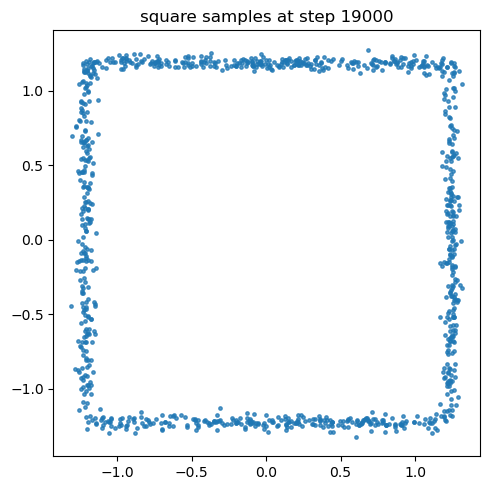

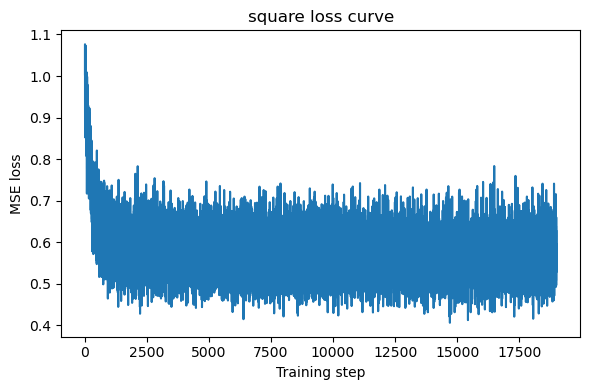

square | step 19100/20000 | loss 0.586534
square | step 19200/20000 | loss 0.549842
square | step 19300/20000 | loss 0.553973
square | step 19400/20000 | loss 0.451986
square | step 19500/20000 | loss 0.510680
square | step 19600/20000 | loss 0.643036
square | step 19700/20000 | loss 0.609043
square | step 19800/20000 | loss 0.495112
square | step 19900/20000 | loss 0.568912
square | step 20000/20000 | loss 0.566005


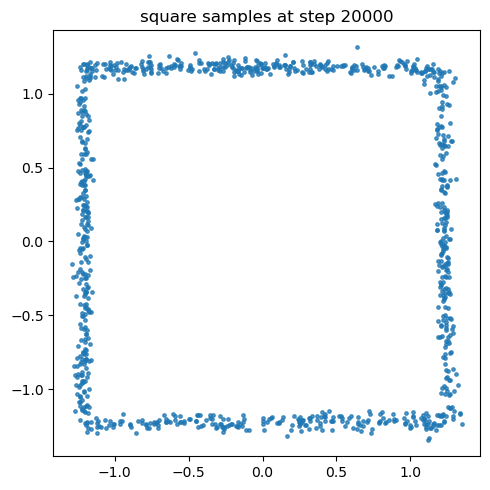

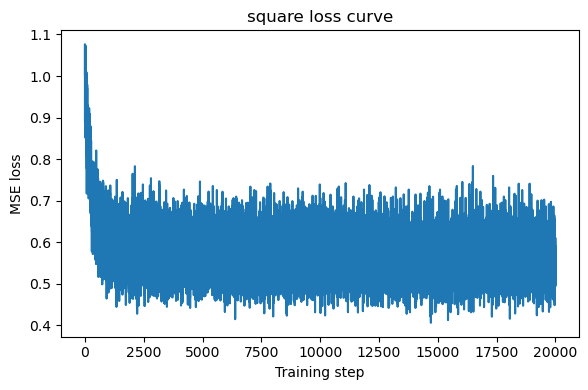

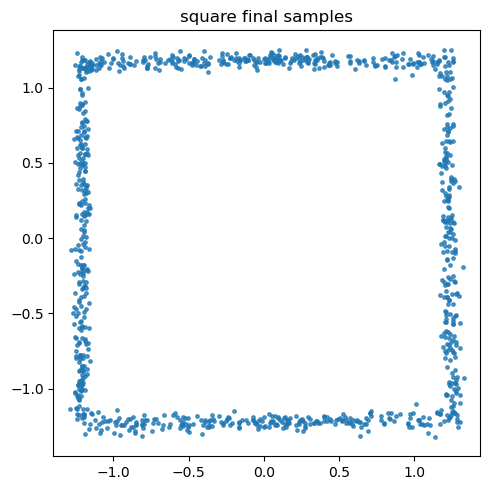

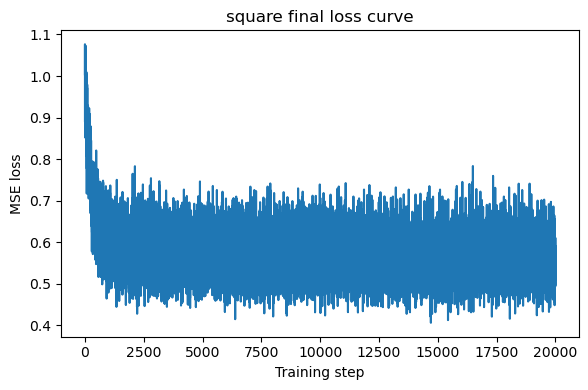

In [28]:
# Train square
square_model, square_diffusion, square_losses = train_one_shape(
    "square",
    square_ds,
    CONFIG,
)

### Training the Dinohead Model

Finally, I train a separate model on the dinosaur-head dataset. This shape is qualitatively more complex and therefore useful for analyzing which structural details are difficult to capture under the assumption that points are generated independently.

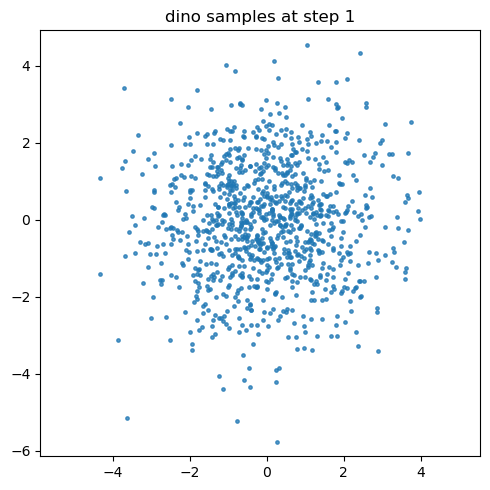

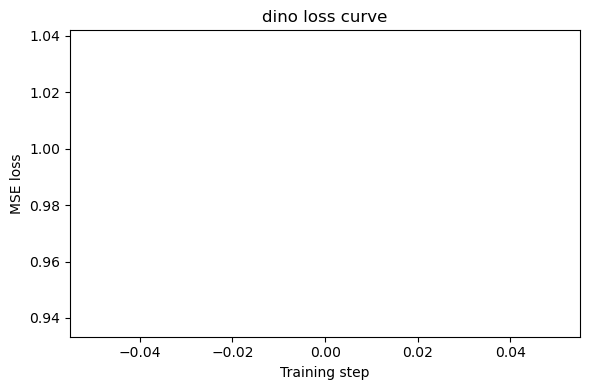

dino | step 100/20000 | loss 0.782512
dino | step 200/20000 | loss 0.729396
dino | step 300/20000 | loss 0.839771
dino | step 400/20000 | loss 0.840724
dino | step 500/20000 | loss 0.790830
dino | step 600/20000 | loss 0.729725
dino | step 700/20000 | loss 0.756588
dino | step 800/20000 | loss 0.821143
dino | step 900/20000 | loss 0.836901
dino | step 1000/20000 | loss 0.797483


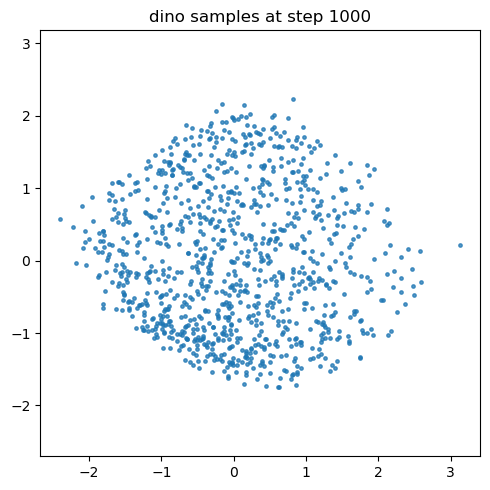

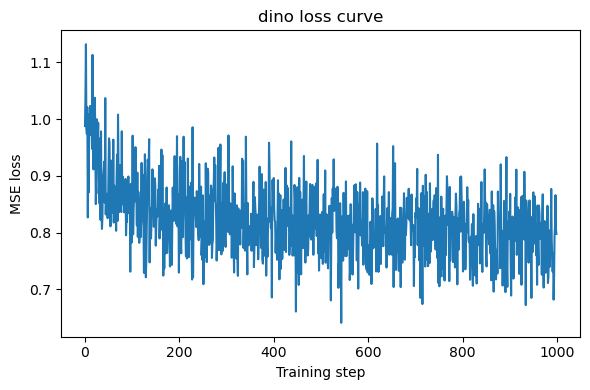

dino | step 1100/20000 | loss 0.724223
dino | step 1200/20000 | loss 0.911180
dino | step 1300/20000 | loss 0.776592
dino | step 1400/20000 | loss 0.762662
dino | step 1500/20000 | loss 0.829099
dino | step 1600/20000 | loss 0.775100
dino | step 1700/20000 | loss 0.732325
dino | step 1800/20000 | loss 0.827208
dino | step 1900/20000 | loss 0.691185
dino | step 2000/20000 | loss 0.690807


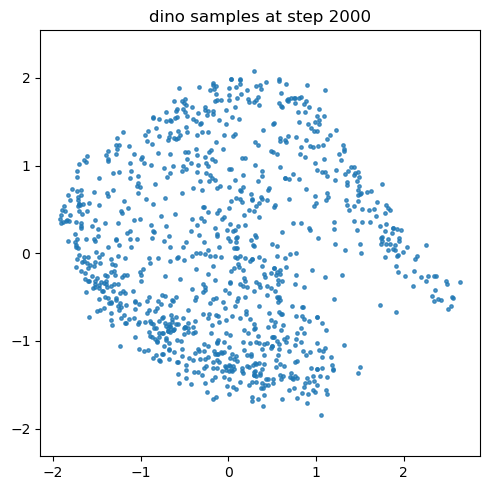

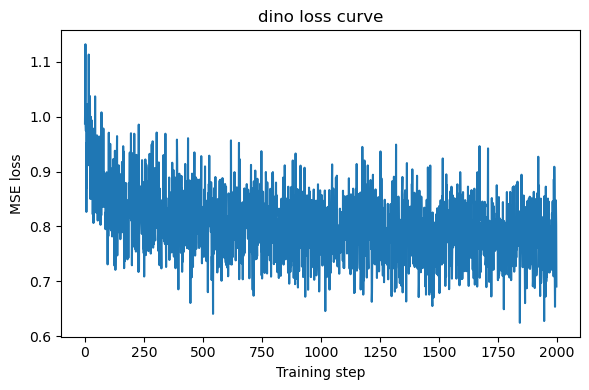

dino | step 2100/20000 | loss 0.693123
dino | step 2200/20000 | loss 0.744648
dino | step 2300/20000 | loss 0.844106
dino | step 2400/20000 | loss 0.772609
dino | step 2500/20000 | loss 0.716107
dino | step 2600/20000 | loss 0.803483
dino | step 2700/20000 | loss 0.781184
dino | step 2800/20000 | loss 0.758098
dino | step 2900/20000 | loss 0.919266
dino | step 3000/20000 | loss 0.790365


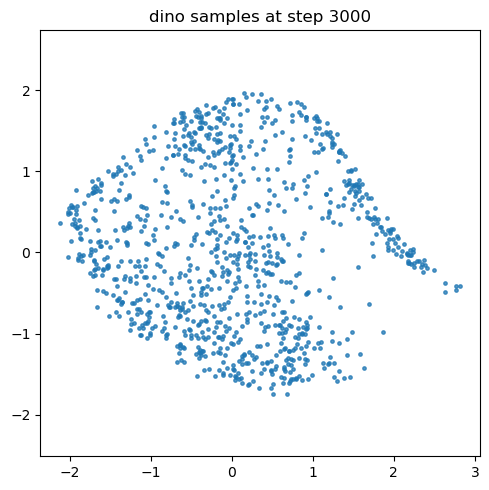

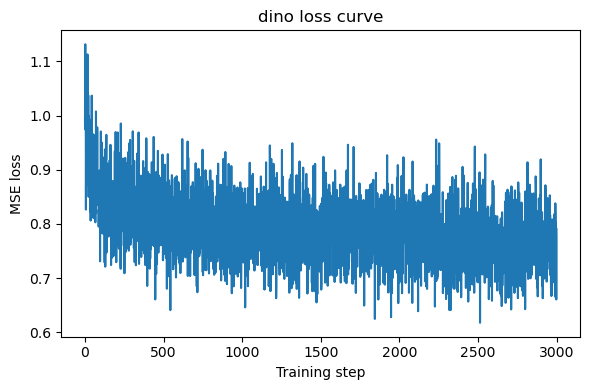

dino | step 3100/20000 | loss 0.779820
dino | step 3200/20000 | loss 0.701070
dino | step 3300/20000 | loss 0.682025
dino | step 3400/20000 | loss 0.819935
dino | step 3500/20000 | loss 0.681263
dino | step 3600/20000 | loss 0.679785
dino | step 3700/20000 | loss 0.816518
dino | step 3800/20000 | loss 0.649746
dino | step 3900/20000 | loss 0.762531
dino | step 4000/20000 | loss 0.721655


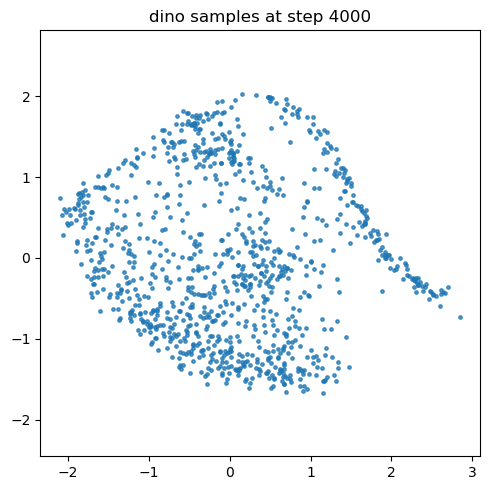

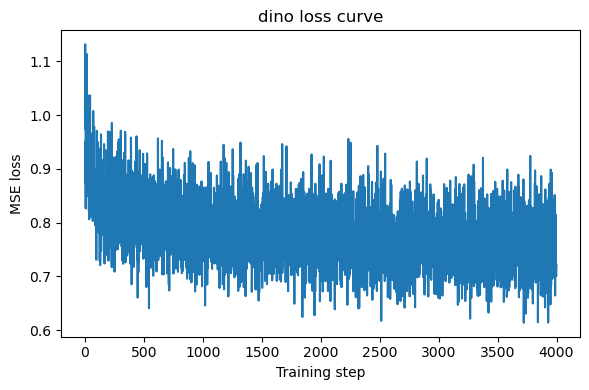

dino | step 4100/20000 | loss 0.700652
dino | step 4200/20000 | loss 0.741998
dino | step 4300/20000 | loss 0.733099
dino | step 4400/20000 | loss 0.838752
dino | step 4500/20000 | loss 0.784971
dino | step 4600/20000 | loss 0.730545
dino | step 4700/20000 | loss 0.753884
dino | step 4800/20000 | loss 0.855568
dino | step 4900/20000 | loss 0.793103
dino | step 5000/20000 | loss 0.651871


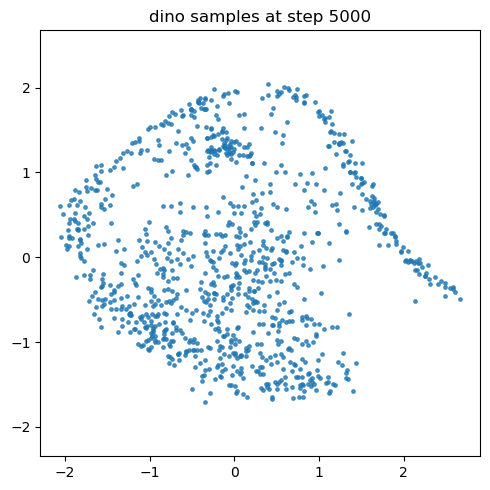

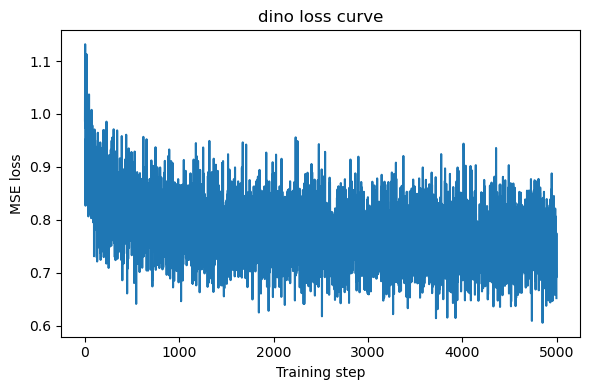

dino | step 5100/20000 | loss 0.832053
dino | step 5200/20000 | loss 0.927527
dino | step 5300/20000 | loss 0.823473
dino | step 5400/20000 | loss 0.751639
dino | step 5500/20000 | loss 0.748283
dino | step 5600/20000 | loss 0.823033
dino | step 5700/20000 | loss 0.766844
dino | step 5800/20000 | loss 0.794307
dino | step 5900/20000 | loss 0.755057
dino | step 6000/20000 | loss 0.703495


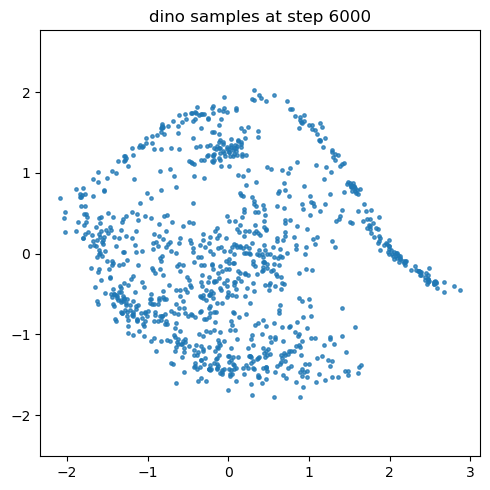

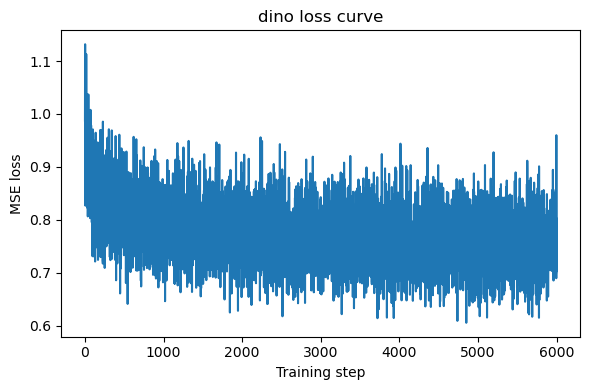

dino | step 6100/20000 | loss 0.765064
dino | step 6200/20000 | loss 0.843487
dino | step 6300/20000 | loss 0.820704
dino | step 6400/20000 | loss 0.733079
dino | step 6500/20000 | loss 0.703282
dino | step 6600/20000 | loss 0.732617
dino | step 6700/20000 | loss 0.734843
dino | step 6800/20000 | loss 0.837404
dino | step 6900/20000 | loss 0.718048
dino | step 7000/20000 | loss 0.757923


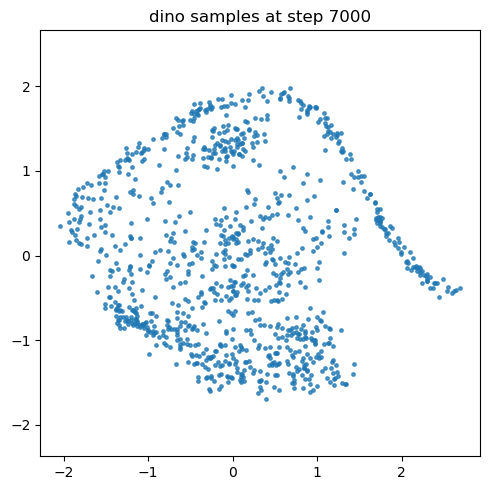

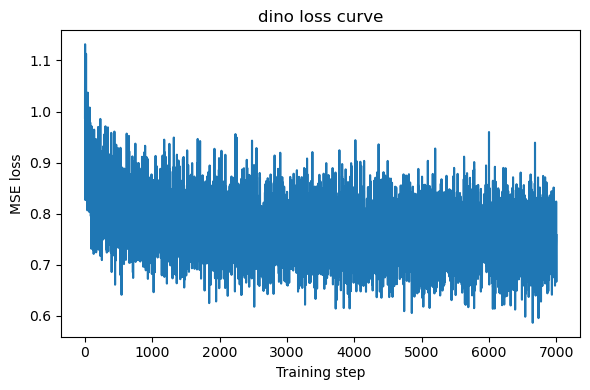

dino | step 7100/20000 | loss 0.633658
dino | step 7200/20000 | loss 0.714082
dino | step 7300/20000 | loss 0.812298
dino | step 7400/20000 | loss 0.807211
dino | step 7500/20000 | loss 0.629387
dino | step 7600/20000 | loss 0.853252
dino | step 7700/20000 | loss 0.689898
dino | step 7800/20000 | loss 0.754232
dino | step 7900/20000 | loss 0.720795
dino | step 8000/20000 | loss 0.675597


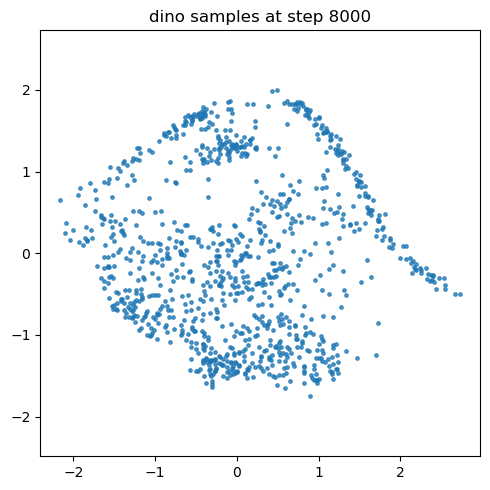

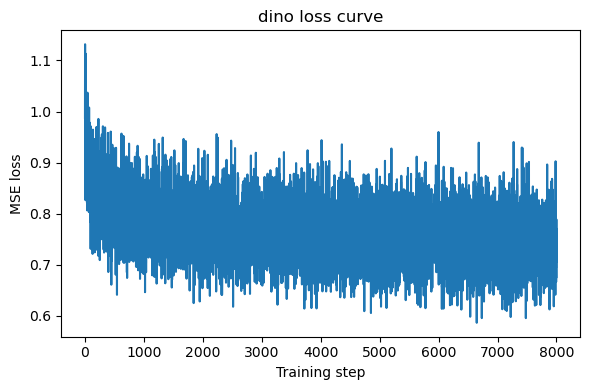

dino | step 8100/20000 | loss 0.712075
dino | step 8200/20000 | loss 0.727282
dino | step 8300/20000 | loss 0.776132
dino | step 8400/20000 | loss 0.699457
dino | step 8500/20000 | loss 0.793542
dino | step 8600/20000 | loss 0.831154
dino | step 8700/20000 | loss 0.740432
dino | step 8800/20000 | loss 0.717005
dino | step 8900/20000 | loss 0.776791
dino | step 9000/20000 | loss 0.713019


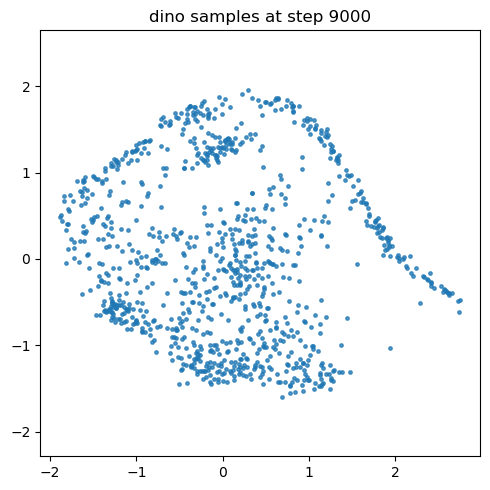

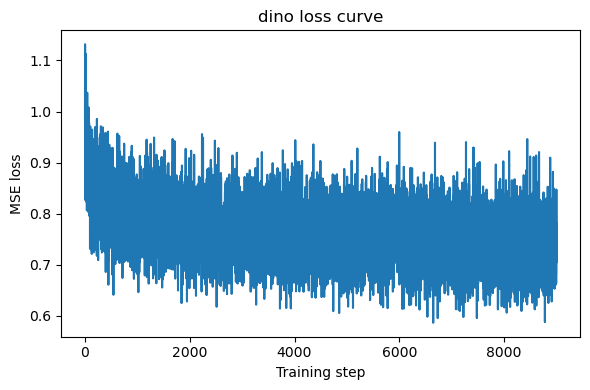

dino | step 9100/20000 | loss 0.695871
dino | step 9200/20000 | loss 0.746929
dino | step 9300/20000 | loss 0.676004
dino | step 9400/20000 | loss 0.725853
dino | step 9500/20000 | loss 0.761971
dino | step 9600/20000 | loss 0.742020
dino | step 9700/20000 | loss 0.761713
dino | step 9800/20000 | loss 0.790847
dino | step 9900/20000 | loss 0.714345
dino | step 10000/20000 | loss 0.769353


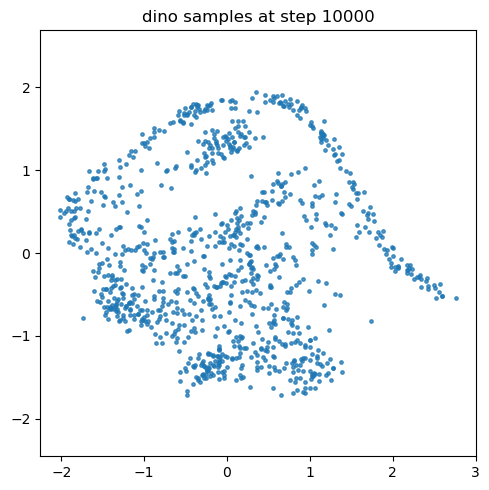

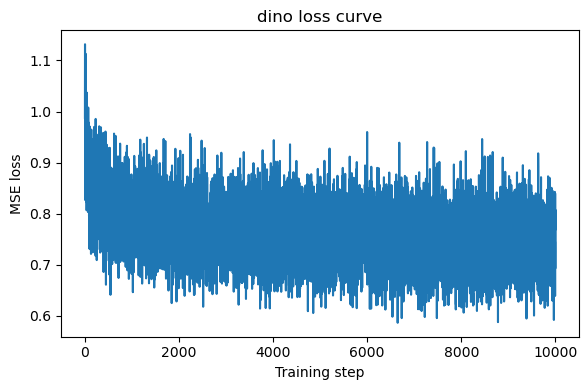

dino | step 10100/20000 | loss 0.760404
dino | step 10200/20000 | loss 0.744524
dino | step 10300/20000 | loss 0.742834
dino | step 10400/20000 | loss 0.813361
dino | step 10500/20000 | loss 0.803038
dino | step 10600/20000 | loss 0.683701
dino | step 10700/20000 | loss 0.701077
dino | step 10800/20000 | loss 0.763450
dino | step 10900/20000 | loss 0.698871
dino | step 11000/20000 | loss 0.734334


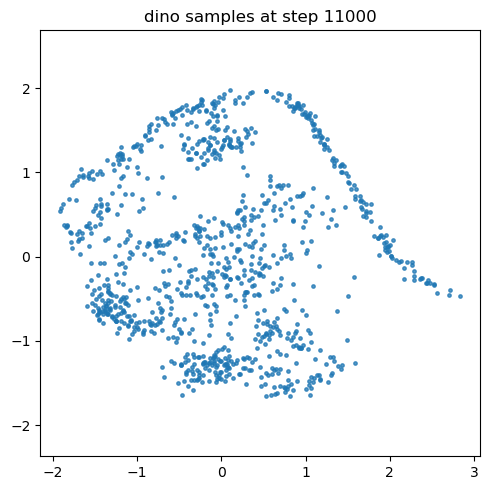

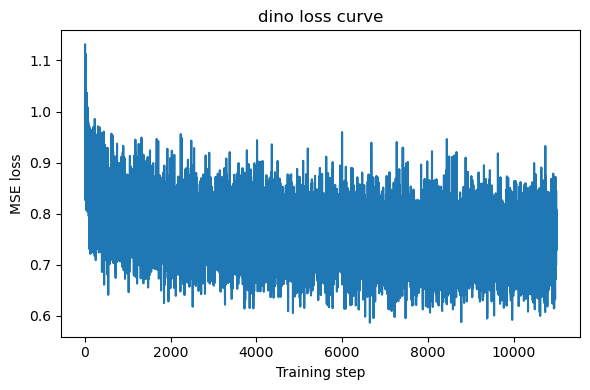

dino | step 11100/20000 | loss 0.778696
dino | step 11200/20000 | loss 0.774518
dino | step 11300/20000 | loss 0.793265
dino | step 11400/20000 | loss 0.753940
dino | step 11500/20000 | loss 0.758269
dino | step 11600/20000 | loss 0.722052
dino | step 11700/20000 | loss 0.738746
dino | step 11800/20000 | loss 0.735681
dino | step 11900/20000 | loss 0.807080
dino | step 12000/20000 | loss 0.724480


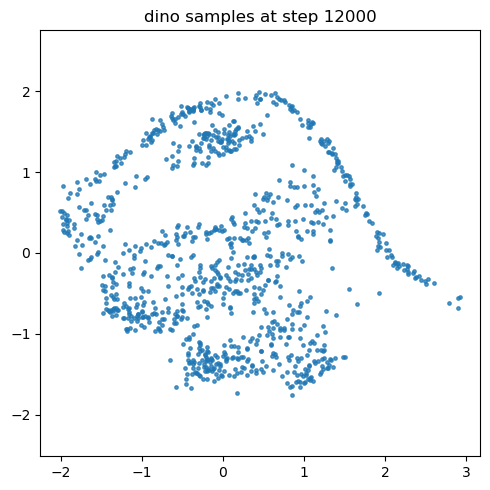

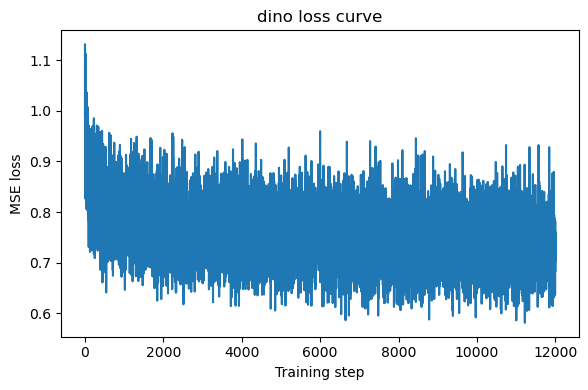

dino | step 12100/20000 | loss 0.734198
dino | step 12200/20000 | loss 0.671697
dino | step 12300/20000 | loss 0.737168
dino | step 12400/20000 | loss 0.764256
dino | step 12500/20000 | loss 0.697505
dino | step 12600/20000 | loss 0.694274
dino | step 12700/20000 | loss 0.719796
dino | step 12800/20000 | loss 0.764359
dino | step 12900/20000 | loss 0.691462
dino | step 13000/20000 | loss 0.719359


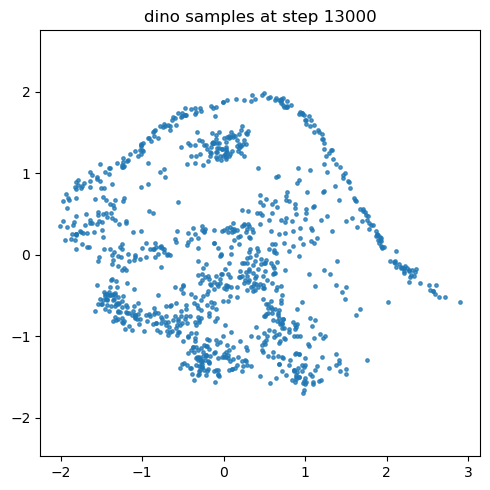

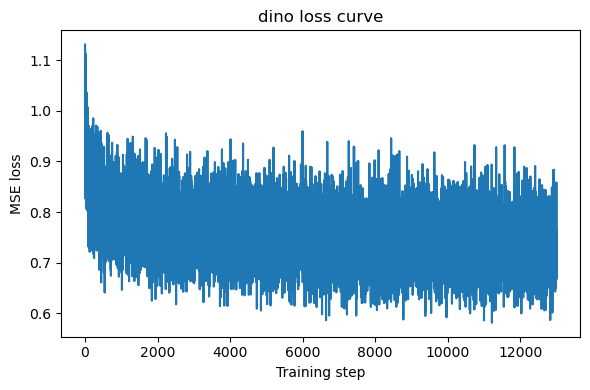

dino | step 13100/20000 | loss 0.725429
dino | step 13200/20000 | loss 0.743239
dino | step 13300/20000 | loss 0.832651
dino | step 13400/20000 | loss 0.767109
dino | step 13500/20000 | loss 0.795723
dino | step 13600/20000 | loss 0.717796
dino | step 13700/20000 | loss 0.659761
dino | step 13800/20000 | loss 0.798850
dino | step 13900/20000 | loss 0.743585
dino | step 14000/20000 | loss 0.671644


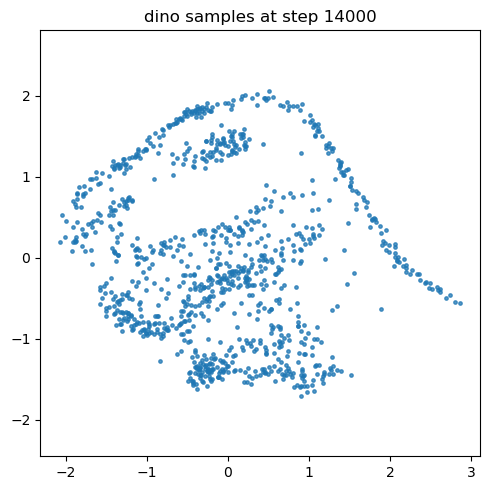

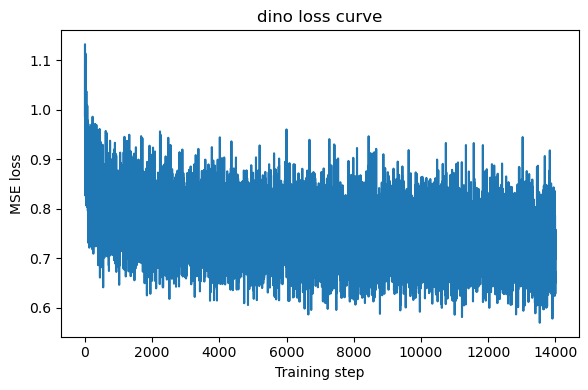

dino | step 14100/20000 | loss 0.646312
dino | step 14200/20000 | loss 0.775360
dino | step 14300/20000 | loss 0.809468
dino | step 14400/20000 | loss 0.636350
dino | step 14500/20000 | loss 0.764803
dino | step 14600/20000 | loss 0.736527
dino | step 14700/20000 | loss 0.722874
dino | step 14800/20000 | loss 0.644565
dino | step 14900/20000 | loss 0.719115
dino | step 15000/20000 | loss 0.714604


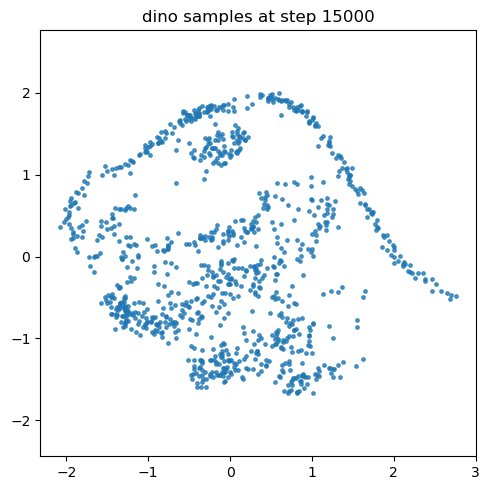

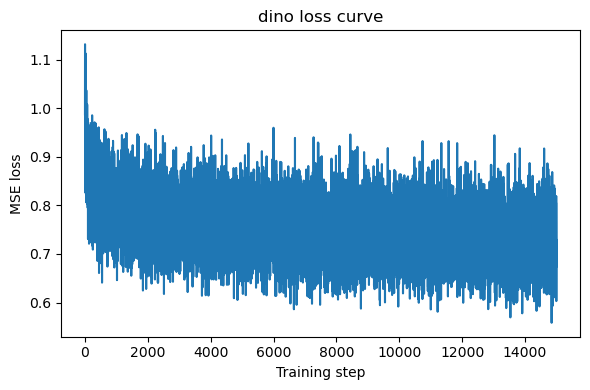

dino | step 15100/20000 | loss 0.697027
dino | step 15200/20000 | loss 0.685855
dino | step 15300/20000 | loss 0.752185
dino | step 15400/20000 | loss 0.600354
dino | step 15500/20000 | loss 0.739638
dino | step 15600/20000 | loss 0.781297
dino | step 15700/20000 | loss 0.835738
dino | step 15800/20000 | loss 0.811071
dino | step 15900/20000 | loss 0.727792
dino | step 16000/20000 | loss 0.665752


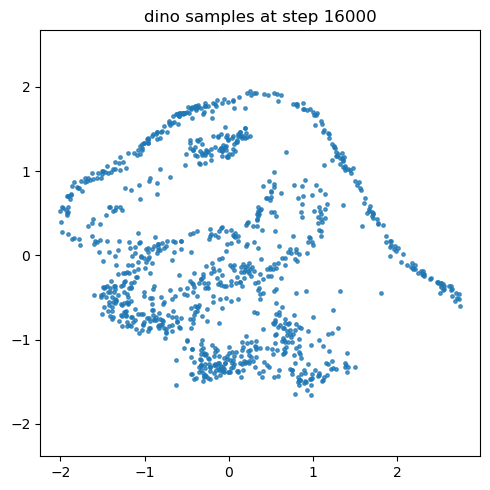

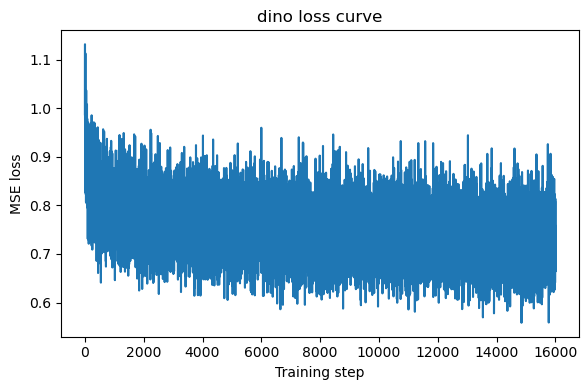

dino | step 16100/20000 | loss 0.736341
dino | step 16200/20000 | loss 0.677935
dino | step 16300/20000 | loss 0.751424
dino | step 16400/20000 | loss 0.655589
dino | step 16500/20000 | loss 0.749224
dino | step 16600/20000 | loss 0.789527
dino | step 16700/20000 | loss 0.793435
dino | step 16800/20000 | loss 0.706392
dino | step 16900/20000 | loss 0.780756
dino | step 17000/20000 | loss 0.720183


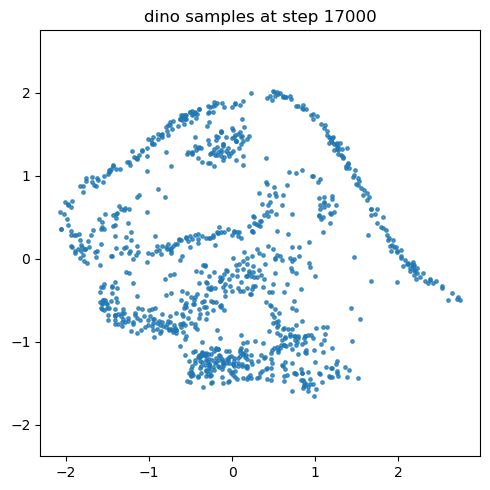

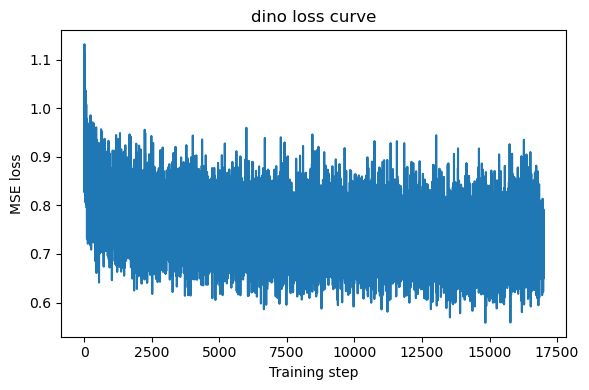

dino | step 17100/20000 | loss 0.703255
dino | step 17200/20000 | loss 0.699474
dino | step 17300/20000 | loss 0.744975
dino | step 17400/20000 | loss 0.750419
dino | step 17500/20000 | loss 0.650640
dino | step 17600/20000 | loss 0.786088
dino | step 17700/20000 | loss 0.690984
dino | step 17800/20000 | loss 0.714028
dino | step 17900/20000 | loss 0.736002
dino | step 18000/20000 | loss 0.731930


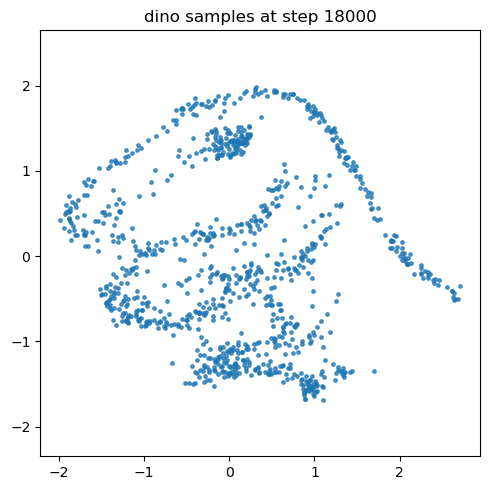

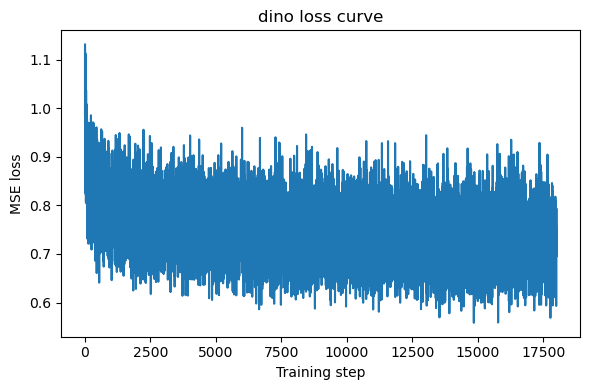

dino | step 18100/20000 | loss 0.693295
dino | step 18200/20000 | loss 0.725543
dino | step 18300/20000 | loss 0.759712
dino | step 18400/20000 | loss 0.822164
dino | step 18500/20000 | loss 0.619684
dino | step 18600/20000 | loss 0.625051
dino | step 18700/20000 | loss 0.718416
dino | step 18800/20000 | loss 0.632125
dino | step 18900/20000 | loss 0.738601
dino | step 19000/20000 | loss 0.681474


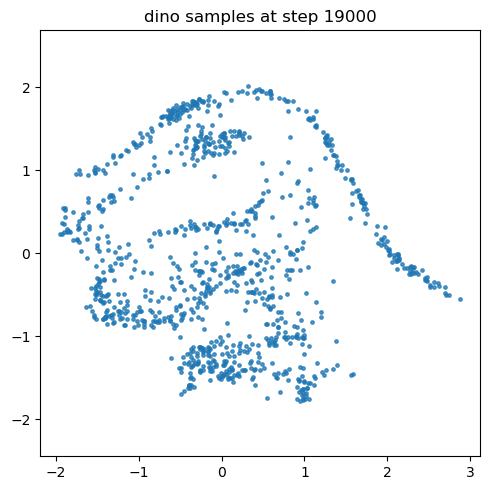

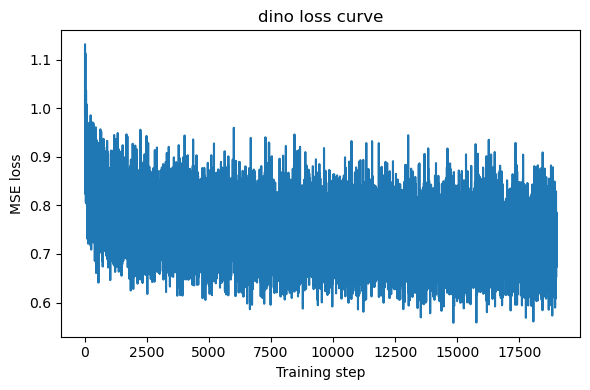

dino | step 19100/20000 | loss 0.618586
dino | step 19200/20000 | loss 0.741190
dino | step 19300/20000 | loss 0.677568
dino | step 19400/20000 | loss 0.712053
dino | step 19500/20000 | loss 0.767731
dino | step 19600/20000 | loss 0.727496
dino | step 19700/20000 | loss 0.674908
dino | step 19800/20000 | loss 0.761310
dino | step 19900/20000 | loss 0.738997
dino | step 20000/20000 | loss 0.740539


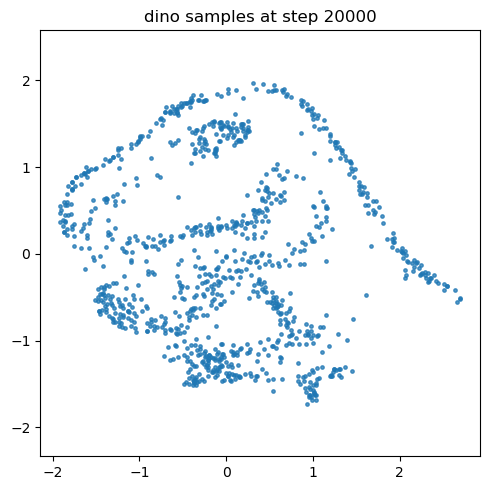

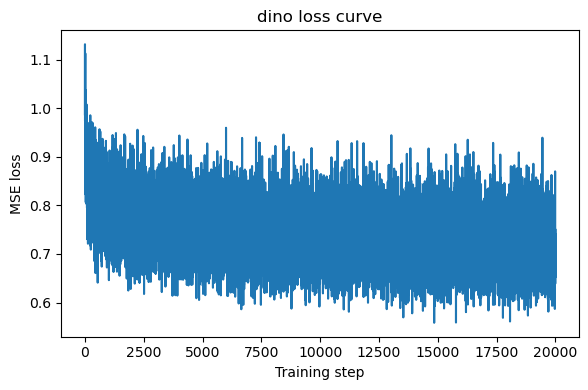

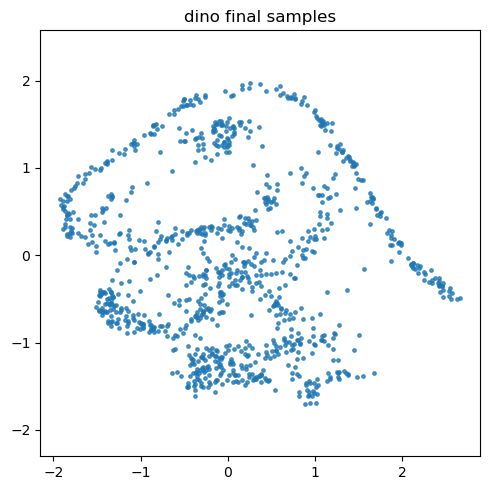

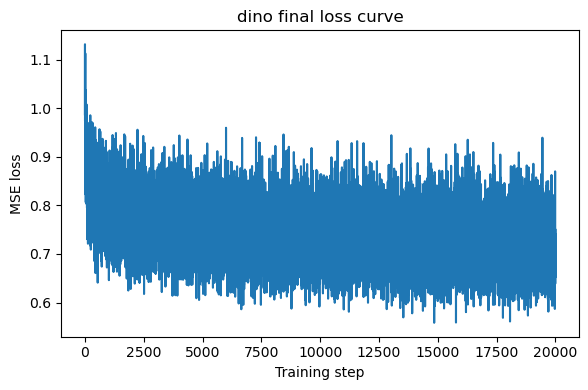

In [29]:
# Train dinohead
dino_model, dino_diffusion, dino_losses = train_one_shape(
    "dino",
    dino_ds,
    CONFIG,
)

## 11. Generated Samples During Training

In this section, I visualize samples produced at different training stages, for example after every 1000 optimization steps. These figures show how the initially unstructured Gaussian samples gradually evolve into recognizable geometric shapes. They also help identify whether the model learns the global structure smoothly or whether it remains noisy, collapses, or develops artifacts.

These intermediate visualizations are an essential part of the experimental evaluation. They provide more information than a loss curve alone, because a decreasing training loss does not automatically imply visually correct samples.

## 12. Final Sampling Results

After training each model to completion, I generate final samples by starting from standard Gaussian noise and running the learned reverse process over all diffusion steps. The resulting point clouds are then compared qualitatively with the corresponding training shapes. The main questions are whether the global geometry is captured correctly, whether the density is distributed sensibly across the shape, and whether any visible artifacts remain.

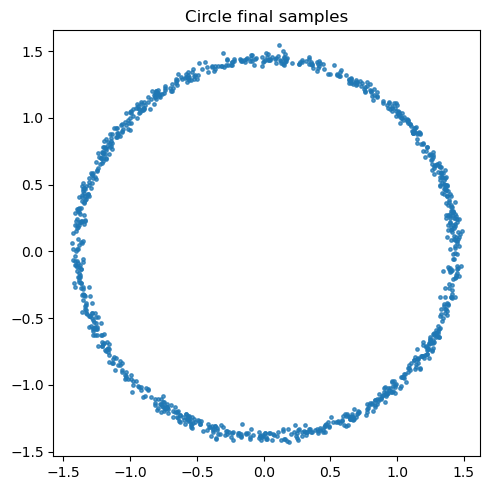

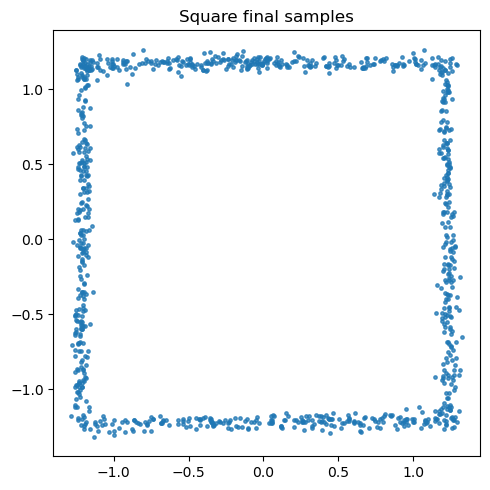

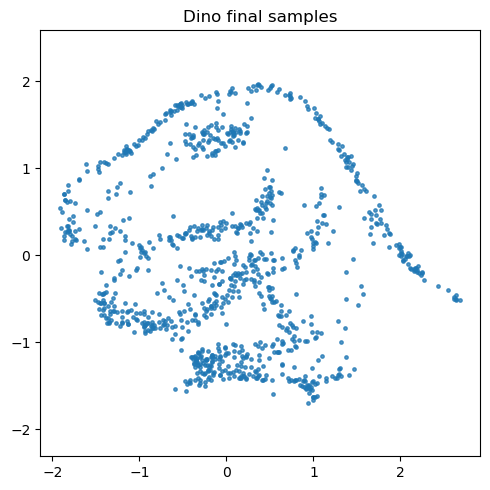

In [30]:
# Final sampling
circle_samples, circle_traj = circle_diffusion.sample(circle_model, 1024, return_trajectory=True)
square_samples, square_traj = square_diffusion.sample(square_model, 1024, return_trajectory=True)
dino_samples, dino_traj = dino_diffusion.sample(dino_model, 1024, return_trajectory=True)

plot_points(circle_samples, title="Circle final samples")
plot_points(square_samples, title="Square final samples")
plot_points(dino_samples, title="Dino final samples")

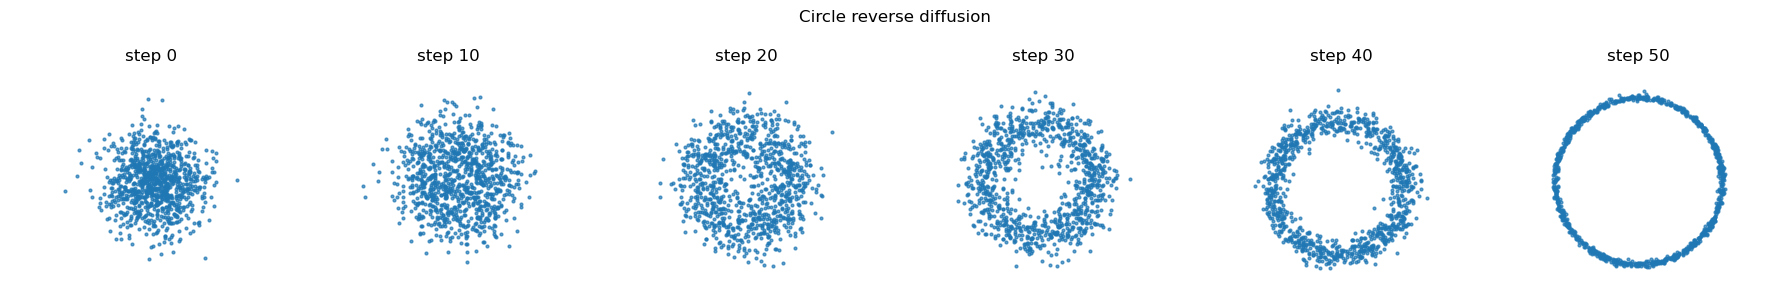

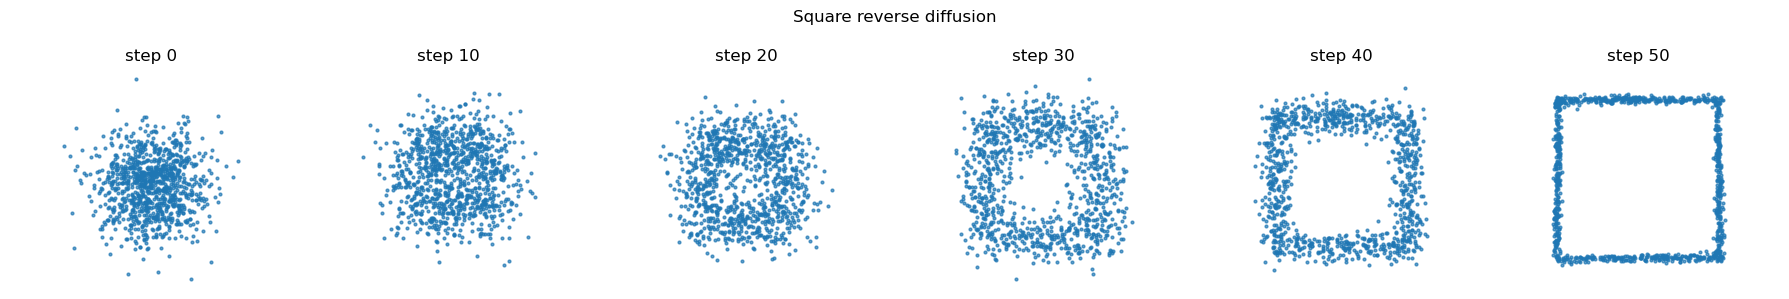

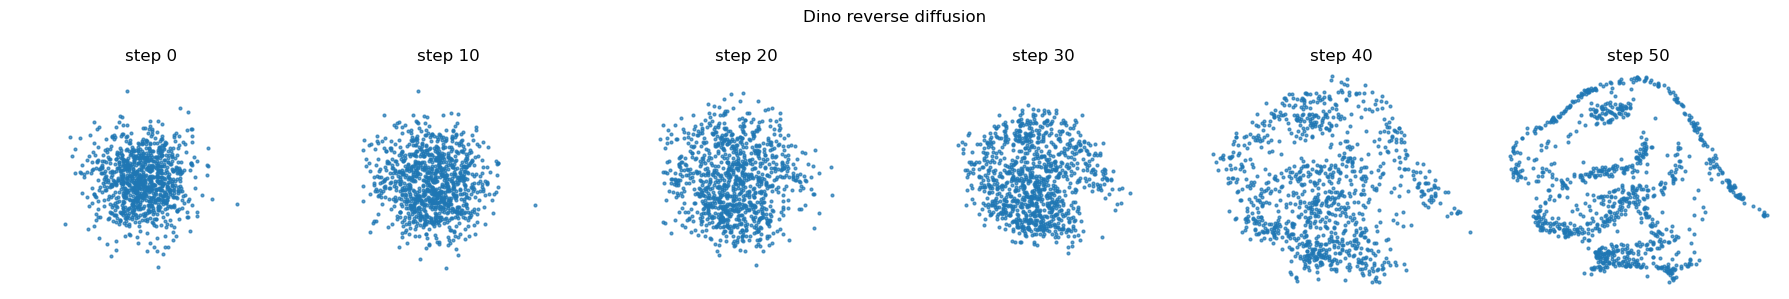

In [31]:
# Reverse-process snapshots
def plot_trajectory_snapshots(trajectory, title="Reverse snapshots", num_snapshots=6):
    idx = np.linspace(0, len(trajectory) - 1, num_snapshots).astype(int)
    fig, axes = plt.subplots(1, num_snapshots, figsize=(3 * num_snapshots, 3))
    for ax, i in zip(axes, idx):
        pts = trajectory[i].numpy()
        ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.7)
        ax.set_title(f"step {i}")
        ax.axis("equal")
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    plt.close()

plot_trajectory_snapshots(circle_traj, title="Circle reverse diffusion")
plot_trajectory_snapshots(square_traj, title="Square reverse diffusion")
plot_trajectory_snapshots(dino_traj, title="Dino reverse diffusion")

## 13. Hyperparameter Analysis

To study the sensitivity of the method, I compare at least one hyperparameter setting while keeping the rest of the training pipeline fixed. Suitable choices include the learning rate, hidden dimensionality, or the variance schedule. The comparison is based on both the loss curves and the visual quality of generated samples.

This analysis is useful for two reasons. First, it provides empirical support for the selected baseline configuration. Second, it gives concrete material for the discussion section of the report, where the training setup and its practical consequences should be described clearly.

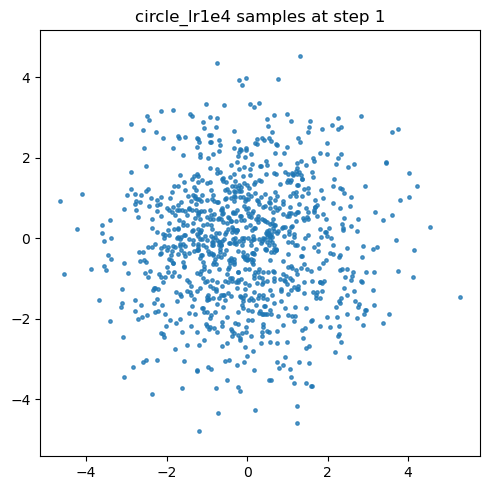

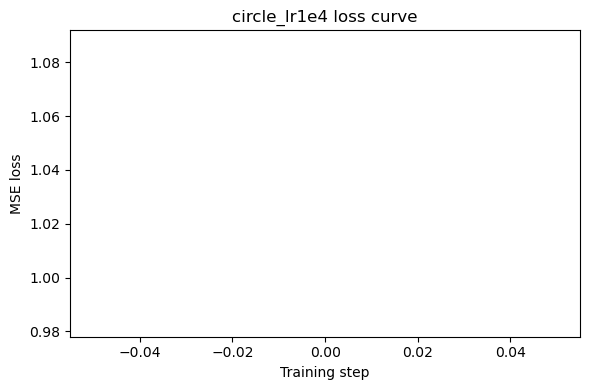

circle_lr1e4 | step 100/20000 | loss 1.059175
circle_lr1e4 | step 200/20000 | loss 0.952093
circle_lr1e4 | step 300/20000 | loss 0.888685
circle_lr1e4 | step 400/20000 | loss 0.899605
circle_lr1e4 | step 500/20000 | loss 0.865797
circle_lr1e4 | step 600/20000 | loss 0.912382
circle_lr1e4 | step 700/20000 | loss 0.829894
circle_lr1e4 | step 800/20000 | loss 0.849043
circle_lr1e4 | step 900/20000 | loss 0.825344
circle_lr1e4 | step 1000/20000 | loss 0.826176


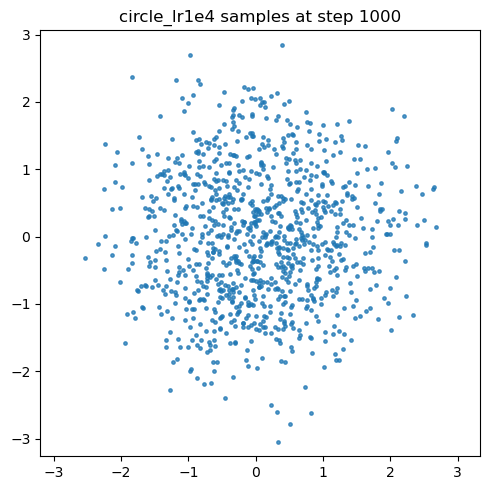

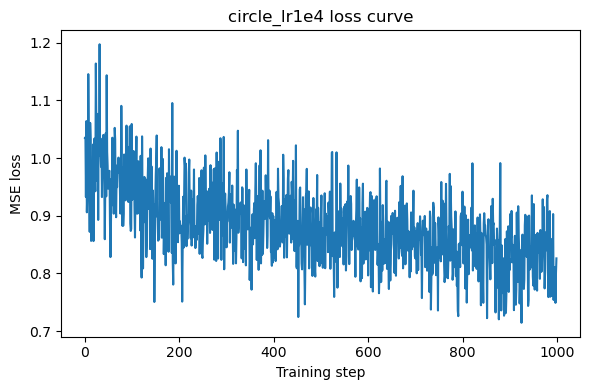

circle_lr1e4 | step 1100/20000 | loss 0.814791
circle_lr1e4 | step 1200/20000 | loss 0.769159
circle_lr1e4 | step 1300/20000 | loss 0.833312
circle_lr1e4 | step 1400/20000 | loss 0.775210
circle_lr1e4 | step 1500/20000 | loss 0.787206
circle_lr1e4 | step 1600/20000 | loss 0.751902
circle_lr1e4 | step 1700/20000 | loss 0.734610
circle_lr1e4 | step 1800/20000 | loss 0.656296
circle_lr1e4 | step 1900/20000 | loss 0.658887
circle_lr1e4 | step 2000/20000 | loss 0.630138


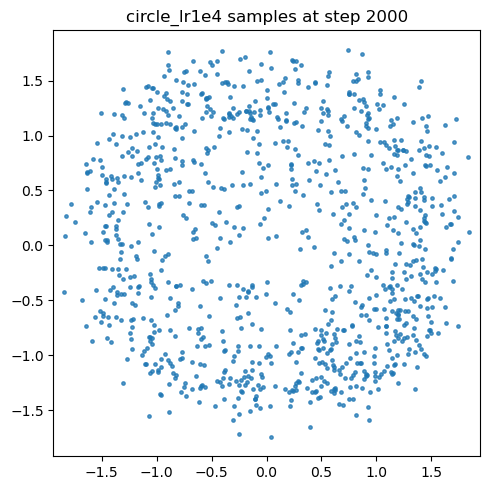

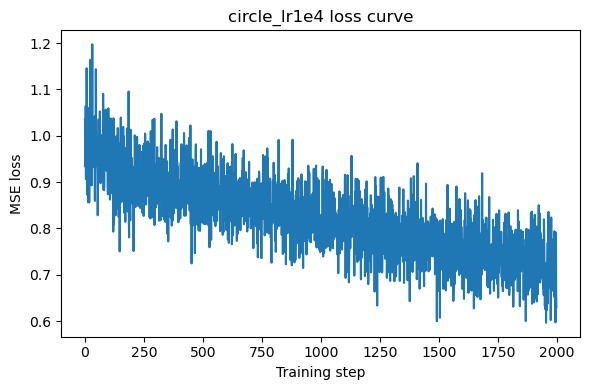

circle_lr1e4 | step 2100/20000 | loss 0.690694
circle_lr1e4 | step 2200/20000 | loss 0.642373
circle_lr1e4 | step 2300/20000 | loss 0.653260
circle_lr1e4 | step 2400/20000 | loss 0.704474
circle_lr1e4 | step 2500/20000 | loss 0.656973
circle_lr1e4 | step 2600/20000 | loss 0.754969
circle_lr1e4 | step 2700/20000 | loss 0.631688
circle_lr1e4 | step 2800/20000 | loss 0.702970
circle_lr1e4 | step 2900/20000 | loss 0.652646
circle_lr1e4 | step 3000/20000 | loss 0.699401


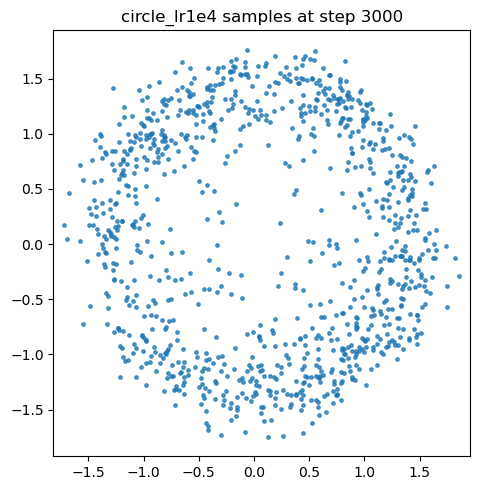

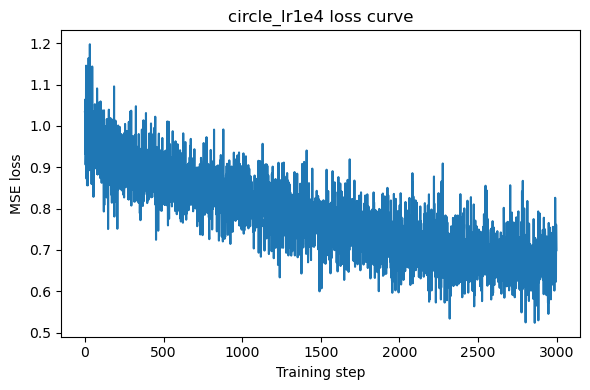

circle_lr1e4 | step 3100/20000 | loss 0.545123
circle_lr1e4 | step 3200/20000 | loss 0.622336
circle_lr1e4 | step 3300/20000 | loss 0.670685
circle_lr1e4 | step 3400/20000 | loss 0.670243
circle_lr1e4 | step 3500/20000 | loss 0.708381
circle_lr1e4 | step 3600/20000 | loss 0.581488
circle_lr1e4 | step 3700/20000 | loss 0.591252
circle_lr1e4 | step 3800/20000 | loss 0.632643
circle_lr1e4 | step 3900/20000 | loss 0.705450
circle_lr1e4 | step 4000/20000 | loss 0.652155


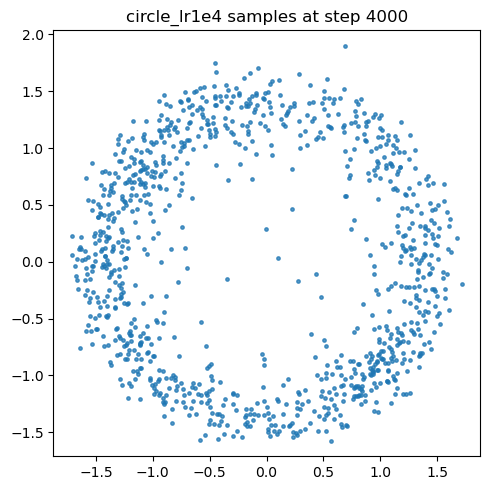

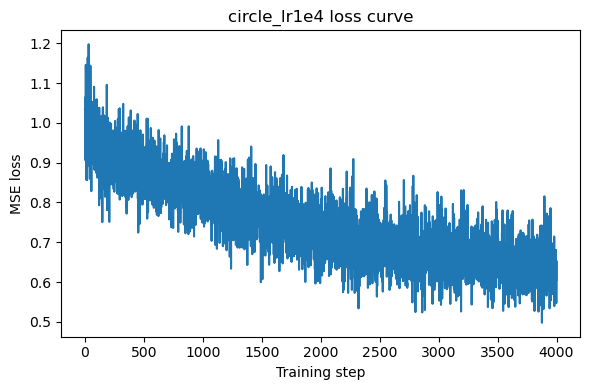

circle_lr1e4 | step 4100/20000 | loss 0.583485
circle_lr1e4 | step 4200/20000 | loss 0.701300
circle_lr1e4 | step 4300/20000 | loss 0.667510
circle_lr1e4 | step 4400/20000 | loss 0.601472
circle_lr1e4 | step 4500/20000 | loss 0.622149
circle_lr1e4 | step 4600/20000 | loss 0.692490
circle_lr1e4 | step 4700/20000 | loss 0.619089
circle_lr1e4 | step 4800/20000 | loss 0.557093
circle_lr1e4 | step 4900/20000 | loss 0.566751
circle_lr1e4 | step 5000/20000 | loss 0.581733


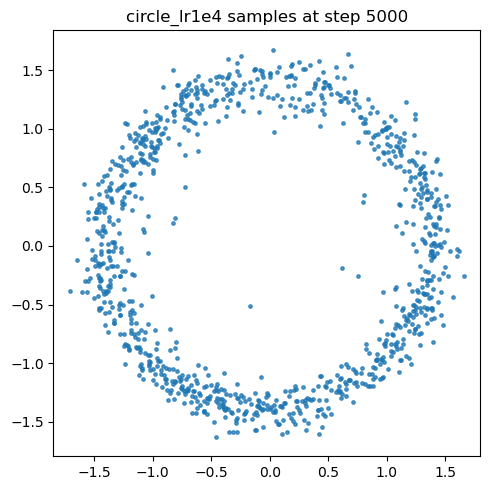

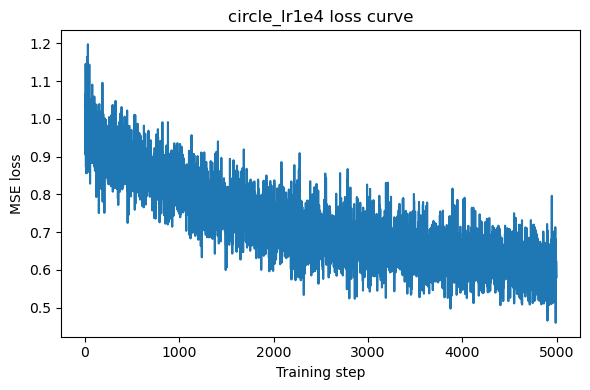

circle_lr1e4 | step 5100/20000 | loss 0.689971
circle_lr1e4 | step 5200/20000 | loss 0.565420
circle_lr1e4 | step 5300/20000 | loss 0.542191
circle_lr1e4 | step 5400/20000 | loss 0.612090
circle_lr1e4 | step 5500/20000 | loss 0.627690
circle_lr1e4 | step 5600/20000 | loss 0.596010
circle_lr1e4 | step 5700/20000 | loss 0.553708
circle_lr1e4 | step 5800/20000 | loss 0.582325
circle_lr1e4 | step 5900/20000 | loss 0.532962
circle_lr1e4 | step 6000/20000 | loss 0.658552


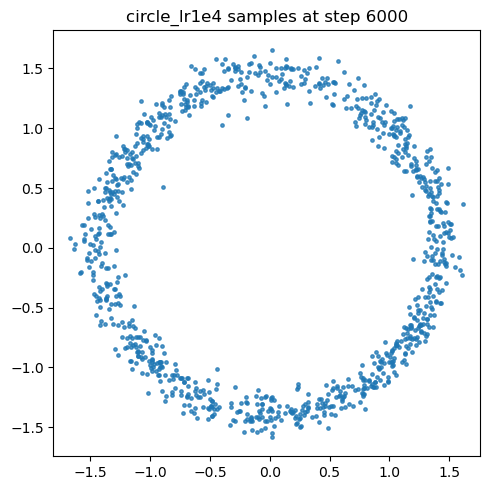

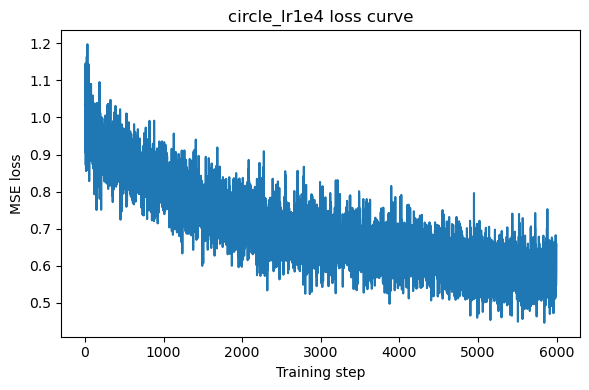

circle_lr1e4 | step 6100/20000 | loss 0.522942
circle_lr1e4 | step 6200/20000 | loss 0.549303
circle_lr1e4 | step 6300/20000 | loss 0.632762
circle_lr1e4 | step 6400/20000 | loss 0.536094
circle_lr1e4 | step 6500/20000 | loss 0.603496
circle_lr1e4 | step 6600/20000 | loss 0.559235
circle_lr1e4 | step 6700/20000 | loss 0.538928
circle_lr1e4 | step 6800/20000 | loss 0.545274
circle_lr1e4 | step 6900/20000 | loss 0.648927
circle_lr1e4 | step 7000/20000 | loss 0.448924


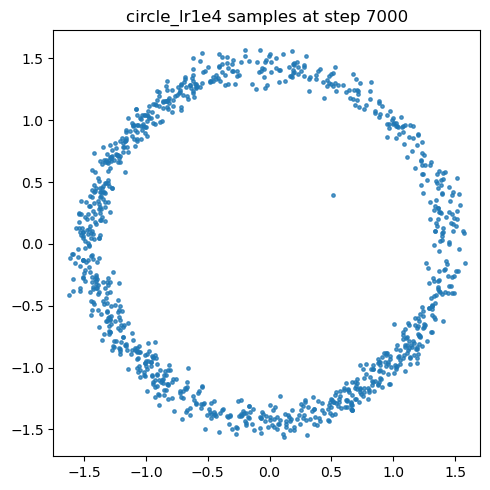

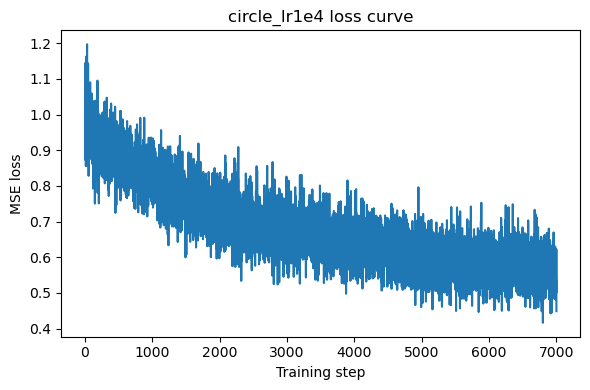

circle_lr1e4 | step 7100/20000 | loss 0.476008
circle_lr1e4 | step 7200/20000 | loss 0.536822
circle_lr1e4 | step 7300/20000 | loss 0.560899
circle_lr1e4 | step 7400/20000 | loss 0.535879
circle_lr1e4 | step 7500/20000 | loss 0.495183
circle_lr1e4 | step 7600/20000 | loss 0.544883
circle_lr1e4 | step 7700/20000 | loss 0.646197
circle_lr1e4 | step 7800/20000 | loss 0.598137
circle_lr1e4 | step 7900/20000 | loss 0.597904
circle_lr1e4 | step 8000/20000 | loss 0.498751


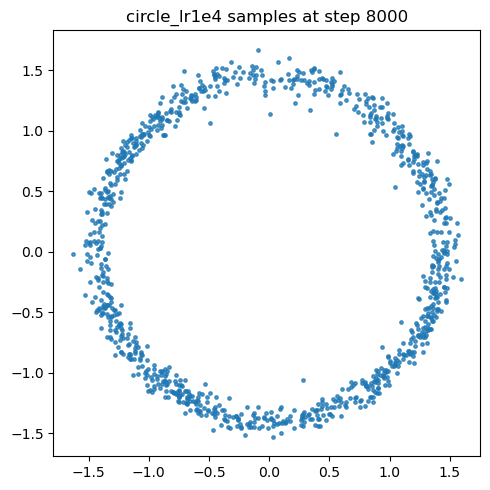

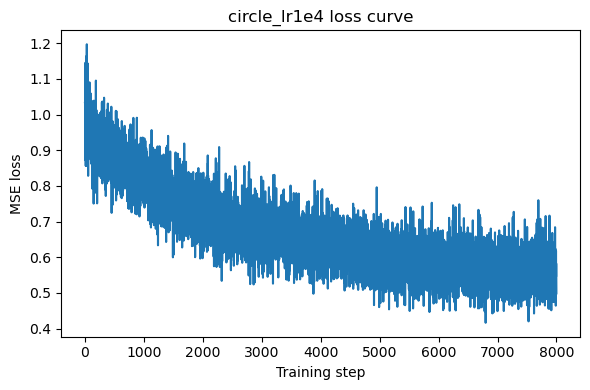

circle_lr1e4 | step 8100/20000 | loss 0.491258
circle_lr1e4 | step 8200/20000 | loss 0.525067
circle_lr1e4 | step 8300/20000 | loss 0.590799
circle_lr1e4 | step 8400/20000 | loss 0.638316
circle_lr1e4 | step 8500/20000 | loss 0.530773
circle_lr1e4 | step 8600/20000 | loss 0.531328
circle_lr1e4 | step 8700/20000 | loss 0.614184
circle_lr1e4 | step 8800/20000 | loss 0.546616
circle_lr1e4 | step 8900/20000 | loss 0.517195
circle_lr1e4 | step 9000/20000 | loss 0.547388


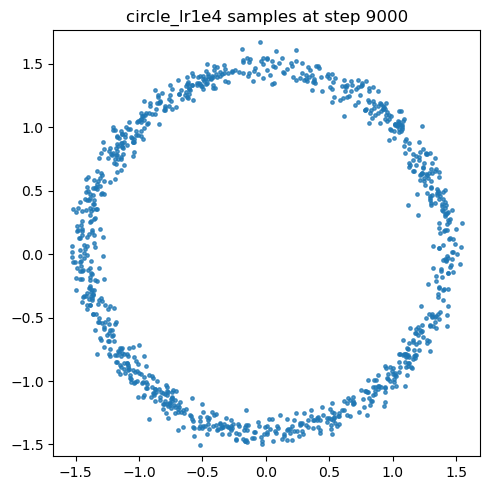

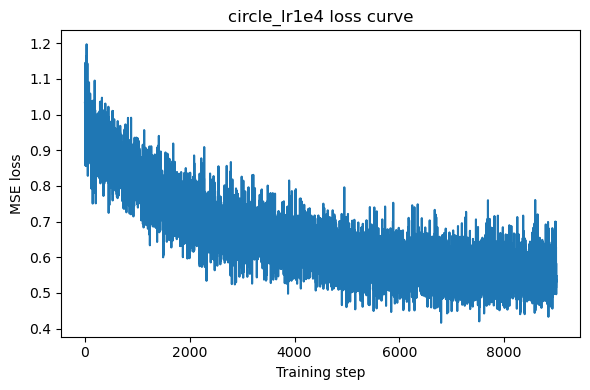

circle_lr1e4 | step 9100/20000 | loss 0.533714
circle_lr1e4 | step 9200/20000 | loss 0.537707
circle_lr1e4 | step 9300/20000 | loss 0.574803
circle_lr1e4 | step 9400/20000 | loss 0.479386
circle_lr1e4 | step 9500/20000 | loss 0.602142
circle_lr1e4 | step 9600/20000 | loss 0.549939
circle_lr1e4 | step 9700/20000 | loss 0.606421
circle_lr1e4 | step 9800/20000 | loss 0.532307
circle_lr1e4 | step 9900/20000 | loss 0.643491
circle_lr1e4 | step 10000/20000 | loss 0.533718


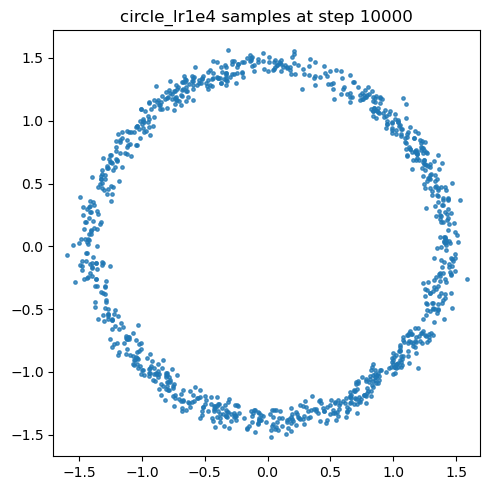

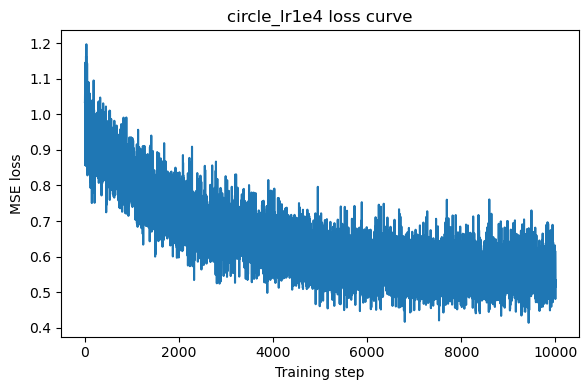

circle_lr1e4 | step 10100/20000 | loss 0.586519
circle_lr1e4 | step 10200/20000 | loss 0.516439
circle_lr1e4 | step 10300/20000 | loss 0.546153
circle_lr1e4 | step 10400/20000 | loss 0.559131
circle_lr1e4 | step 10500/20000 | loss 0.600853
circle_lr1e4 | step 10600/20000 | loss 0.573176
circle_lr1e4 | step 10700/20000 | loss 0.580653
circle_lr1e4 | step 10800/20000 | loss 0.554833
circle_lr1e4 | step 10900/20000 | loss 0.515964
circle_lr1e4 | step 11000/20000 | loss 0.546945


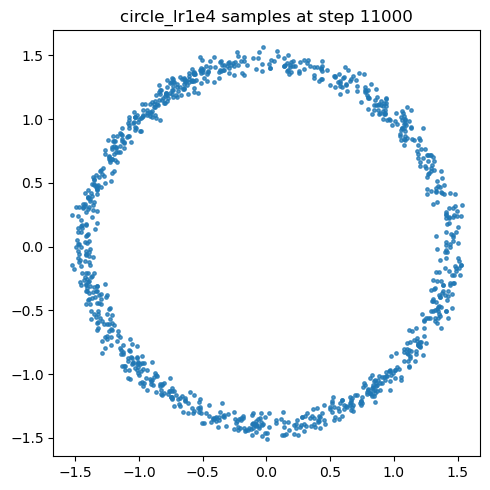

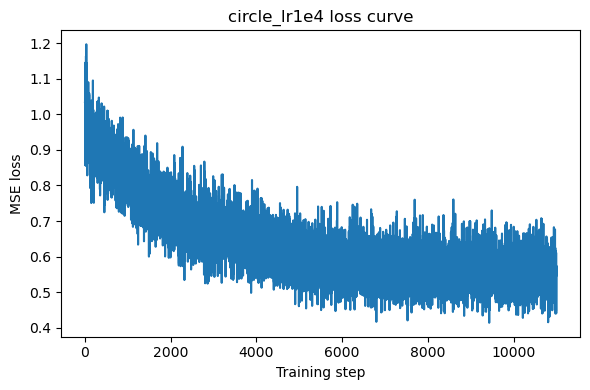

circle_lr1e4 | step 11100/20000 | loss 0.486498
circle_lr1e4 | step 11200/20000 | loss 0.571282
circle_lr1e4 | step 11300/20000 | loss 0.580671
circle_lr1e4 | step 11400/20000 | loss 0.586262
circle_lr1e4 | step 11500/20000 | loss 0.510724
circle_lr1e4 | step 11600/20000 | loss 0.535253
circle_lr1e4 | step 11700/20000 | loss 0.616024
circle_lr1e4 | step 11800/20000 | loss 0.659209
circle_lr1e4 | step 11900/20000 | loss 0.577840
circle_lr1e4 | step 12000/20000 | loss 0.588144


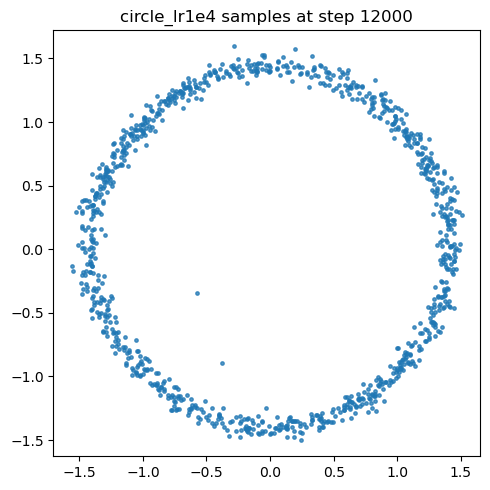

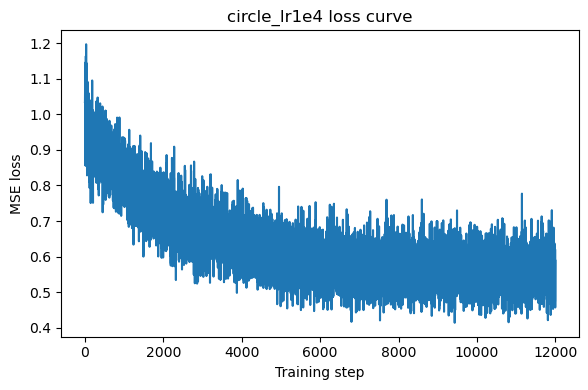

circle_lr1e4 | step 12100/20000 | loss 0.506344
circle_lr1e4 | step 12200/20000 | loss 0.587224
circle_lr1e4 | step 12300/20000 | loss 0.436640
circle_lr1e4 | step 12400/20000 | loss 0.550290
circle_lr1e4 | step 12500/20000 | loss 0.549741
circle_lr1e4 | step 12600/20000 | loss 0.510103
circle_lr1e4 | step 12700/20000 | loss 0.615369
circle_lr1e4 | step 12800/20000 | loss 0.643450
circle_lr1e4 | step 12900/20000 | loss 0.553702
circle_lr1e4 | step 13000/20000 | loss 0.502150


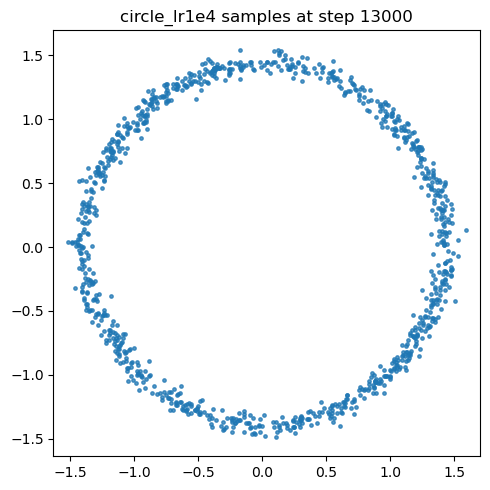

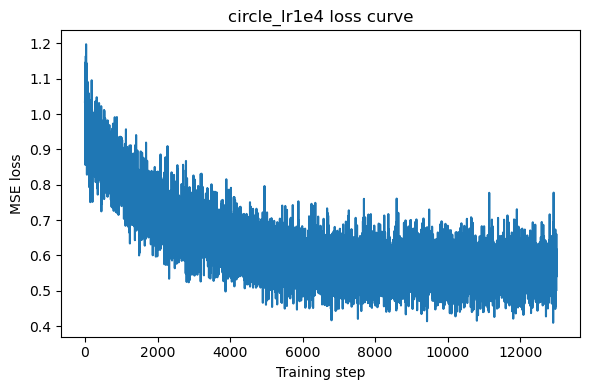

circle_lr1e4 | step 13100/20000 | loss 0.536896
circle_lr1e4 | step 13200/20000 | loss 0.507254
circle_lr1e4 | step 13300/20000 | loss 0.554271
circle_lr1e4 | step 13400/20000 | loss 0.584603
circle_lr1e4 | step 13500/20000 | loss 0.532251
circle_lr1e4 | step 13600/20000 | loss 0.547293
circle_lr1e4 | step 13700/20000 | loss 0.483883
circle_lr1e4 | step 13800/20000 | loss 0.628943
circle_lr1e4 | step 13900/20000 | loss 0.511662
circle_lr1e4 | step 14000/20000 | loss 0.531728


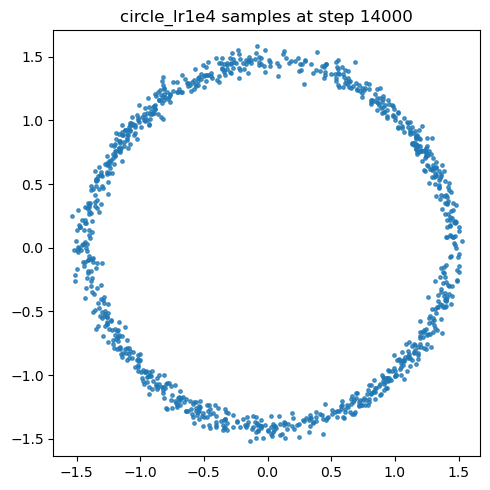

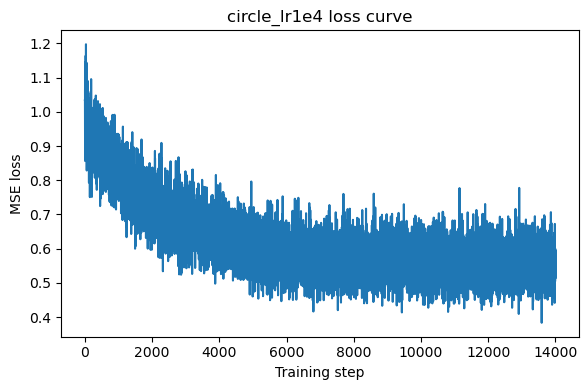

circle_lr1e4 | step 14100/20000 | loss 0.579094
circle_lr1e4 | step 14200/20000 | loss 0.512795
circle_lr1e4 | step 14300/20000 | loss 0.514941
circle_lr1e4 | step 14400/20000 | loss 0.546115
circle_lr1e4 | step 14500/20000 | loss 0.489957
circle_lr1e4 | step 14600/20000 | loss 0.603701
circle_lr1e4 | step 14700/20000 | loss 0.595692
circle_lr1e4 | step 14800/20000 | loss 0.518073
circle_lr1e4 | step 14900/20000 | loss 0.547275
circle_lr1e4 | step 15000/20000 | loss 0.505688


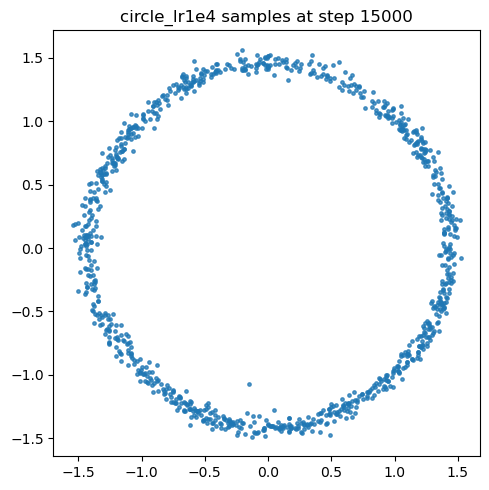

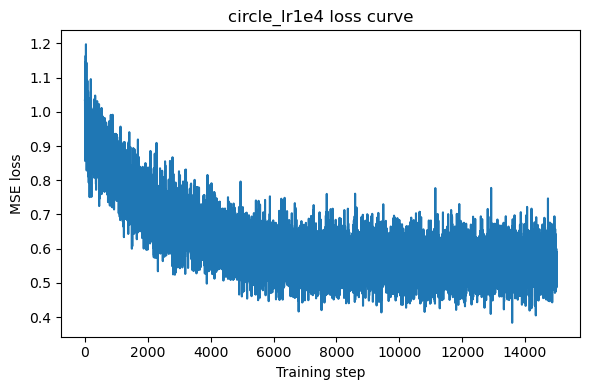

circle_lr1e4 | step 15100/20000 | loss 0.585432
circle_lr1e4 | step 15200/20000 | loss 0.557659
circle_lr1e4 | step 15300/20000 | loss 0.563771
circle_lr1e4 | step 15400/20000 | loss 0.603087
circle_lr1e4 | step 15500/20000 | loss 0.544787
circle_lr1e4 | step 15600/20000 | loss 0.512204
circle_lr1e4 | step 15700/20000 | loss 0.542237
circle_lr1e4 | step 15800/20000 | loss 0.520561
circle_lr1e4 | step 15900/20000 | loss 0.503254
circle_lr1e4 | step 16000/20000 | loss 0.557903


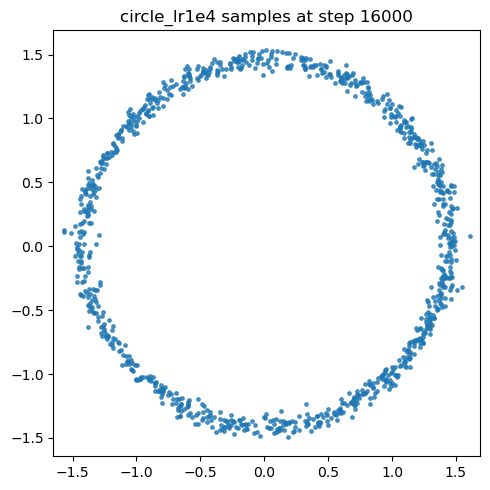

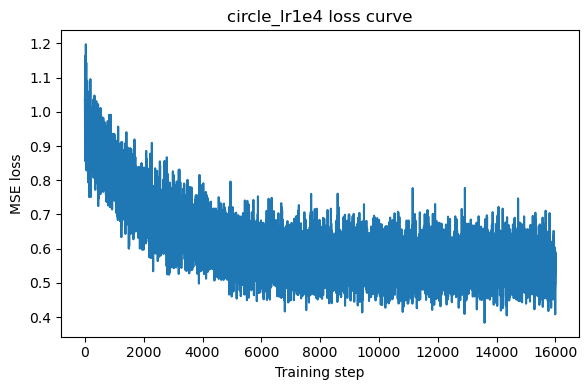

circle_lr1e4 | step 16100/20000 | loss 0.521053
circle_lr1e4 | step 16200/20000 | loss 0.567445
circle_lr1e4 | step 16300/20000 | loss 0.544810
circle_lr1e4 | step 16400/20000 | loss 0.499104
circle_lr1e4 | step 16500/20000 | loss 0.618352
circle_lr1e4 | step 16600/20000 | loss 0.534876
circle_lr1e4 | step 16700/20000 | loss 0.508663
circle_lr1e4 | step 16800/20000 | loss 0.507807
circle_lr1e4 | step 16900/20000 | loss 0.523767
circle_lr1e4 | step 17000/20000 | loss 0.512602


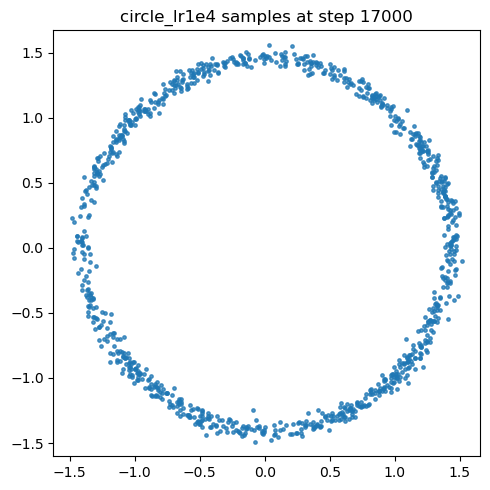

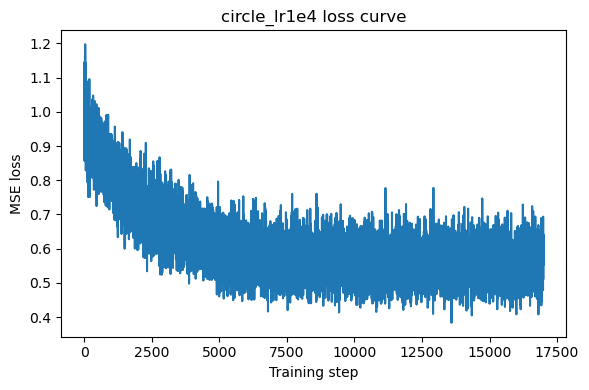

circle_lr1e4 | step 17100/20000 | loss 0.472809
circle_lr1e4 | step 17200/20000 | loss 0.620208
circle_lr1e4 | step 17300/20000 | loss 0.540181
circle_lr1e4 | step 17400/20000 | loss 0.584491
circle_lr1e4 | step 17500/20000 | loss 0.500877
circle_lr1e4 | step 17600/20000 | loss 0.579646
circle_lr1e4 | step 17700/20000 | loss 0.525118
circle_lr1e4 | step 17800/20000 | loss 0.539676
circle_lr1e4 | step 17900/20000 | loss 0.606850
circle_lr1e4 | step 18000/20000 | loss 0.564422


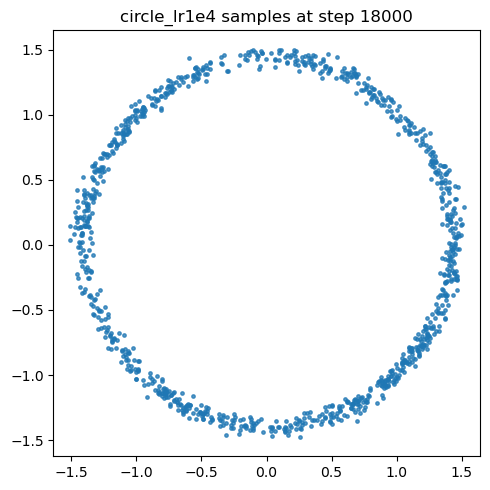

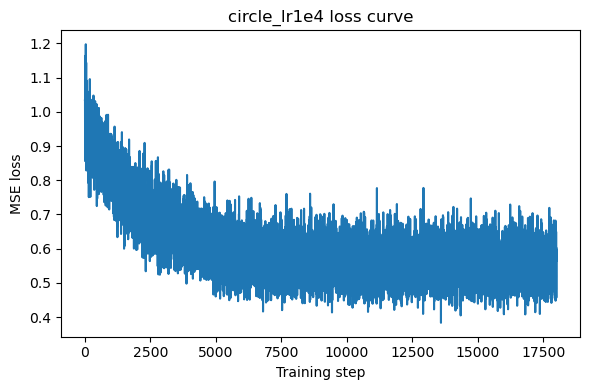

circle_lr1e4 | step 18100/20000 | loss 0.690186
circle_lr1e4 | step 18200/20000 | loss 0.599791
circle_lr1e4 | step 18300/20000 | loss 0.466331
circle_lr1e4 | step 18400/20000 | loss 0.571465
circle_lr1e4 | step 18500/20000 | loss 0.596449
circle_lr1e4 | step 18600/20000 | loss 0.523453
circle_lr1e4 | step 18700/20000 | loss 0.573881
circle_lr1e4 | step 18800/20000 | loss 0.570481
circle_lr1e4 | step 18900/20000 | loss 0.610704
circle_lr1e4 | step 19000/20000 | loss 0.502710


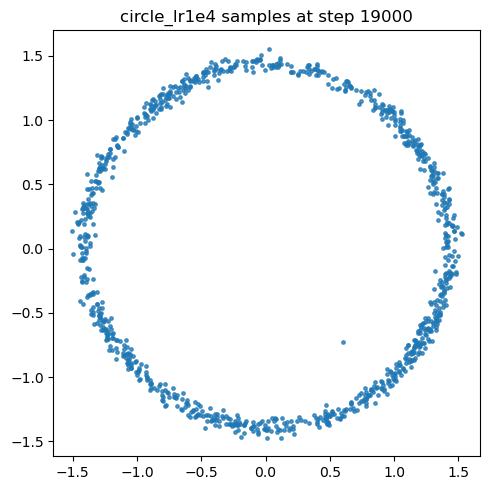

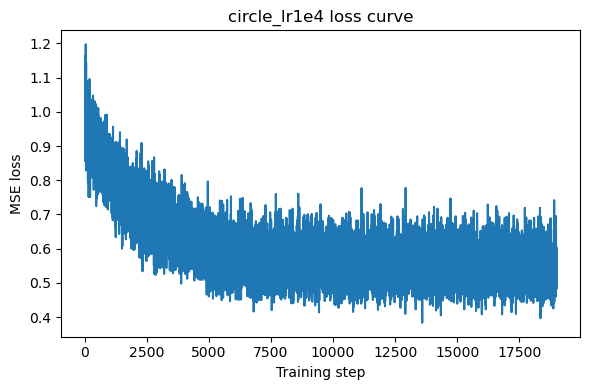

circle_lr1e4 | step 19100/20000 | loss 0.616790
circle_lr1e4 | step 19200/20000 | loss 0.508195
circle_lr1e4 | step 19300/20000 | loss 0.577304
circle_lr1e4 | step 19400/20000 | loss 0.585380
circle_lr1e4 | step 19500/20000 | loss 0.558117
circle_lr1e4 | step 19600/20000 | loss 0.569935
circle_lr1e4 | step 19700/20000 | loss 0.559499
circle_lr1e4 | step 19800/20000 | loss 0.525157
circle_lr1e4 | step 19900/20000 | loss 0.536700
circle_lr1e4 | step 20000/20000 | loss 0.565391


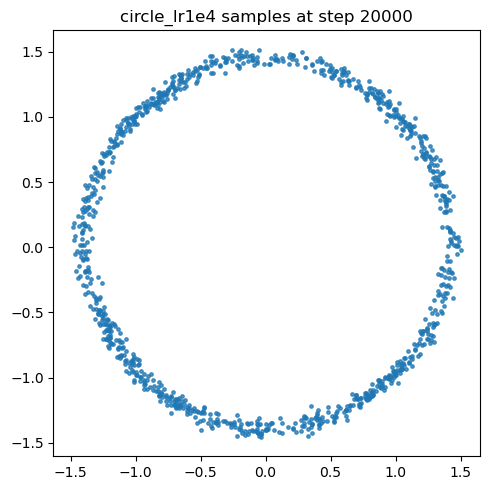

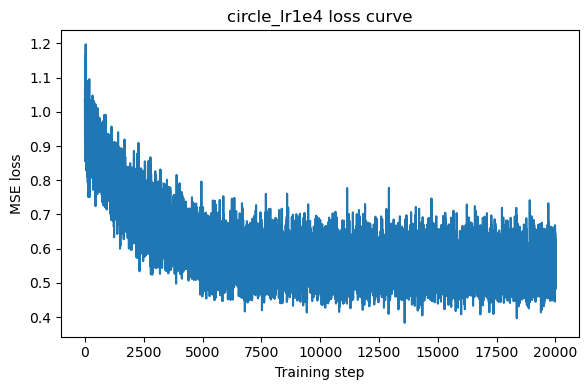

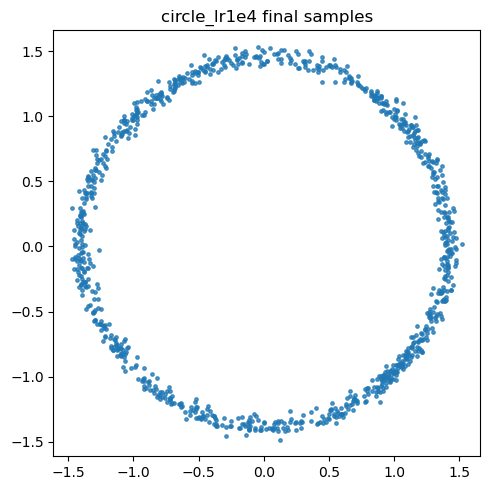

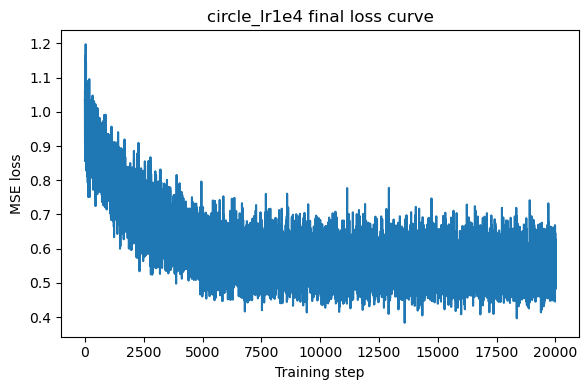

In [32]:
# Hyperparameter section
CONFIG_LR_SMALL = CONFIG.copy()
CONFIG_LR_SMALL["lr"] = 1e-4

# Example:
circle_model_lr_small, _, circle_losses_lr_small = train_one_shape(
    "circle_lr1e4",
    circle_ds,
    CONFIG_LR_SMALL,
)

## 14. Qualitative Artifacts

Even when the generated samples resemble the target shape, they may still contain visible artifacts. Examples include blurred boundaries, missing corners, uneven density, disconnected local regions, or small clusters outside the main structure. Such effects are especially informative in this project because the theoretical part asks for a discussion of artifacts caused by the assumption that points are generated independently.

In the discussion below, I connect these artifacts to the limitations of independent-point generation. Since the network predicts each point without jointly enforcing global structure across the entire point cloud, some geometric relationships are inherently difficult to preserve.

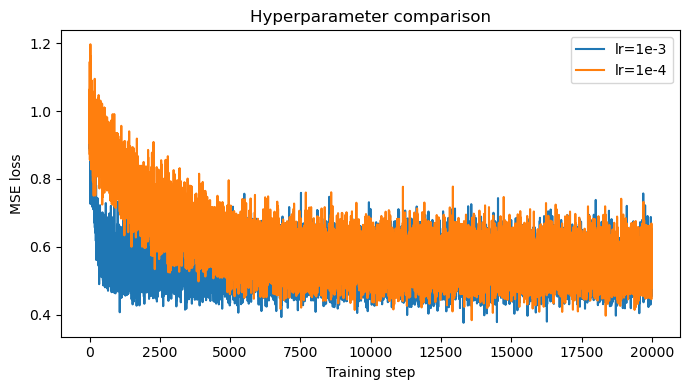

In [33]:
# Compare losses
def compare_loss_curves(loss_dict):
    plt.figure(figsize=(7, 4))
    for name, losses in loss_dict.items():
        plt.plot(losses, label=name)
    plt.xlabel("Training step")
    plt.ylabel("MSE loss")
    plt.title("Hyperparameter comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

# Example:
compare_loss_curves({
    "lr=1e-3": circle_losses,
    "lr=1e-4": circle_losses_lr_small,
})

## 15. Optional Advanced Part

The advanced part extends the model from independent-point generation to joint point-cloud generation. The core idea is that the denoising model should not rely only on a single noisy point, but should also receive information about the entire batch or point cloud. Such additional information should be permutation invariant, for example in the form of pooled statistics over all points.

I include a scaffold for this extension here, but I keep it clearly separated from the mandatory implementation. This helps preserve a clean baseline while making it possible to explore stronger geometric modeling if needed.

In [34]:
#  advanced
class GlobalConditionedMLP(nn.Module):
    def __init__(self, base_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(base_dim + 4, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, point_features, batch_points):
        mean = batch_points.mean(dim=0, keepdim=True).repeat(batch_points.size(0), 1)
        var = batch_points.var(dim=0, keepdim=True).repeat(batch_points.size(0), 1)
        x = torch.cat([point_features, mean, var], dim=-1)
        return self.net(x)

In [35]:
# Save key figures list
report_figures = [
    "outputs/task1/forward_trajectories.png",
    "outputs/task1/xt_histogram.png",
    "outputs/task1/reverse_trajectories.png",
    "outputs/task1/recovered_x0_histogram.png",
    "outputs/task2/circle/final_samples.png",
    "outputs/task2/square/final_samples.png",
    "outputs/task2/dino/final_samples.png",
]
report_figures

['outputs/task1/forward_trajectories.png',
 'outputs/task1/xt_histogram.png',
 'outputs/task1/reverse_trajectories.png',
 'outputs/task1/recovered_x0_histogram.png',
 'outputs/task2/circle/final_samples.png',
 'outputs/task2/square/final_samples.png',
 'outputs/task2/dino/final_samples.png']